# CReST: Final Cross-System Evaluation

Evaluates frozen final models on previously unseen education systems, including reconstruction, nuisance probes, disjoint-item transfer, and domain/process increments.

In [ ]:
import warnings
warnings.filterwarnings('ignore')

In [ ]:
# Final CReST evaluation environment

from pathlib import Path
import json
import hashlib

import numpy as np
import pandas as pd
import torch


BASE_DIR = Path.cwd()

HANDOFF_DIR = (
    BASE_DIR
    / "processed"
    / "crest_v5_handoff"
)

FINAL_RESOURCE_ROOT = (
    BASE_DIR
    / "processed"
    / "crest_final_7fold"
)

FINAL_TEST_ROOT = (
    BASE_DIR
    / "processed"
    / "crest_final_test_sets"
)

CHECKPOINT_ROOT = (
    BASE_DIR
    / "checkpoints"
    / "final_7fold"
)

RESULTS_DIR = (
    BASE_DIR
    / "results"
)

FIG_DIR = (
    BASE_DIR
    / "figures"
)


FINAL_TEST_ROOT.mkdir(
    parents=True,
    exist_ok=True
)

RESULTS_DIR.mkdir(
    exist_ok=True
)

FIG_DIR.mkdir(
    exist_ok=True
)


# Locked configuration

with open(
    HANDOFF_DIR / "handoff_config.json",
    "r",
    encoding="utf-8"
) as f:
    CONFIG = json.load(f)


with open(
    RESULTS_DIR / "crest_final_architecture_lock.json",
    "r",
    encoding="utf-8"
) as f:
    ARCHITECTURE_LOCK = json.load(f)


with open(
    RESULTS_DIR / "crest_final_training_protocol.json",
    "r",
    encoding="utf-8"
) as f:
    FINAL_TRAINING_PROTOCOL = json.load(f)


final_training_summary = pd.read_csv(
    RESULTS_DIR
    / "crest_final_7fold_training_summary.csv"
)


primary_meta = pd.read_pickle(
    HANDOFF_DIR
    / "primary_meta.pkl"
)


assert (
    ARCHITECTURE_LOCK[
        "architecture_status"
    ]
    == "LOCKED"
)

assert (
    len(
        final_training_summary
    )
    == 7
)

assert (
    final_training_summary[
        "test_evaluated"
    ]
    .eq(False)
    .all()
)


device = torch.device(
    "cuda"
    if torch.cuda.is_available()
    else "cpu"
)


print(
    "Architecture:",
    ARCHITECTURE_LOCK[
        "architecture_name"
    ]
)

print(
    "Final trained folds:",
    len(
        final_training_summary
    )
)

print(
    "Education systems:",
    primary_meta[
        "CNT"
    ].nunique()
)

print(
    "Students:",
    len(
        primary_meta
    )
)

print(
    "Device:",
    device
)

print(
    "\nAll final TEST sets are still unevaluated: PASS"
)

Architecture: CReST-Final
Final trained folds: 7
Education systems: 63
Students: 142564
Device: cpu

All final TEST sets are still unevaluated: PASS


In [ ]:
# Freeze and archive the seven held-out TEST sets

N_FOLDS = 7

test_manifest_rows = []
all_test_indices = []


for outer_fold in range(
    N_FOLDS
):

    fold_dir = (
        FINAL_TEST_ROOT
        / f"fold_{outer_fold}"
    )

    fold_dir.mkdir(
        parents=True,
        exist_ok=True
    )


    # Exact held-out rows

    test_idx = np.where(
        primary_meta[
            "country_fold"
        ].to_numpy()
        == outer_fold
    )[0].astype(
        np.int64
    )


    test_meta = (
        primary_meta.iloc[
            test_idx
        ]
        .copy()
    )


    test_meta.insert(
        0,
        "handoff_row_index",
        test_idx
    )


    test_countries = sorted(
        test_meta[
            "CNT"
        ]
        .unique()
        .tolist()
    )


    # Save exact row indices + metadata

    index_path = (
        fold_dir
        / "test_indices.npy"
    )


    metadata_path = (
        fold_dir
        / "test_metadata.csv"
    )


    np.save(
        index_path,
        test_idx
    )


    test_meta.to_csv(
        metadata_path,
        index=False
    )


    # Hash exact index file for reproducibility

    sha256 = hashlib.sha256(
        index_path.read_bytes()
    ).hexdigest()


    test_manifest_rows.append(
        {
            "outer_fold":
                outer_fold,

            "n_students":
                len(
                    test_idx
                ),

            "n_systems":
                len(
                    test_countries
                ),

            "systems":
                "|".join(
                    test_countries
                ),

            "indices_sha256":
                sha256,

            "evaluated":
                False
        }
    )


    all_test_indices.append(
        test_idx
    )


test_manifest = pd.DataFrame(
    test_manifest_rows
)


test_manifest.to_csv(

    FINAL_TEST_ROOT
    / "test_set_manifest.csv",

    index=False
)


print(
    test_manifest[
        [
            "outer_fold",
            "n_students",
            "n_systems",
            "evaluated"
        ]
    ].to_string(
        index=False
    )
)

 outer_fold  n_students  n_systems  evaluated
          0       21649          9      False
          1       20949          9      False
          2       20769          9      False
          3       20324          9      False
          4       19460          9      False
          5       19694          9      False
          6       19719          9      False


In [ ]:
# Final TEST partition integrity audit

all_test_indices = np.concatenate(
    all_test_indices
)


unique_test_indices, counts = np.unique(
    all_test_indices,
    return_counts=True
)


assert (
    len(
        all_test_indices
    )
    == len(
        primary_meta
    )
)


assert (
    len(
        unique_test_indices
    )
    == len(
        primary_meta
    )
)


assert (
    counts.min()
    == 1
)

assert (
    counts.max()
    == 1
)


# Every system must belong to exactly one held-out fold.
country_fold_counts = (
    primary_meta[
        [
            "CNT",
            "country_fold"
        ]
    ]
    .drop_duplicates()
    .groupby(
        "CNT"
    )[
        "country_fold"
    ]
    .nunique()
)


assert (
    country_fold_counts.eq(
        1
    ).all()
)


# Seven trained checkpoints must exist.
for fold in range(
    7
):

    checkpoint_path = (
        CHECKPOINT_ROOT
        / f"fold_{fold}"
        / "crest_final_best.pt"
    )

    assert checkpoint_path.exists(), (
        f"Missing checkpoint: {checkpoint_path}"
    )


print(
    "Total archived TEST students:",
    len(
        all_test_indices
    )
)

print(
    "Unique TEST students:",
    len(
        unique_test_indices
    )
)

print(
    "Education systems:",
    len(
        country_fold_counts
    )
)

print(
    "Checkpoints:",
    7
)

print(
    "\nEvery student appears exactly once "
    "as held-out TEST: PASS"
)

print(
    "Every education system belongs to "
    "exactly one TEST fold: PASS"
)

print(
    "All seven final checkpoints present: PASS"
)

print(
    "\nTEST evaluation has NOT started yet."
)

Total archived TEST students: 142564
Unique TEST students: 142564
Education systems: 63
Checkpoints: 7

Every student appears exactly once as held-out TEST: PASS
Every education system belongs to exactly one TEST fold: PASS
All seven final checkpoints present: PASS

TEST evaluation has NOT started yet.


In [ ]:
%%writefile crest_final_core.py

import numpy as np
import pandas as pd

import torch
import torch.nn as nn
import torch.nn.functional as F

from torch.utils.data import Dataset


# Preprocessors

class ContextPreprocessor:

    def __init__(
        self,
        registry=None,
        variables=None
    ):

        self.continuous_vars = []
        self.categorical_vars = []

        self.medians = {}
        self.iqrs = {}
        self.category_maps = {}

        if (
            registry is not None
            and
            variables is not None
        ):

            reg = registry.loc[
                registry["variable"].isin(
                    variables
                )
            ].copy()

            self.continuous_vars = (
                reg.loc[
                    reg["feature_type"]
                    == "continuous",
                    "variable"
                ]
                .tolist()
            )

            self.categorical_vars = (
                reg.loc[
                    reg["feature_type"].isin(
                        [
                            "categorical",
                            "binary",
                            "ordinal"
                        ]
                    ),
                    "variable"
                ]
                .tolist()
            )


    def fit(
        self,
        df,
        indices
    ):

        train_df = df.iloc[
            indices
        ]


        for var in self.continuous_vars:

            x = pd.to_numeric(
                train_df[var],
                errors="coerce"
            )

            median = x.median()

            iqr = (
                x.quantile(0.75)
                -
                x.quantile(0.25)
            )

            if (
                not np.isfinite(iqr)
                or
                iqr < 1e-8
            ):
                iqr = 1.0

            self.medians[var] = float(
                median
            )

            self.iqrs[var] = float(
                iqr
            )


        for var in self.categorical_vars:

            values = sorted(
                train_df[var]
                .dropna()
                .unique()
                .tolist(),
                key=str
            )

            self.category_maps[var] = {
                value: i + 2

                for i, value
                in enumerate(values)
            }


        return self


    def transform(
        self,
        df
    ):

        n = len(df)

        cont_values = []
        cont_masks = []


        for var in self.continuous_vars:

            x = pd.to_numeric(
                df[var],
                errors="coerce"
            ).to_numpy(
                dtype=np.float32
            )

            observed = np.isfinite(
                x
            )

            z = (
                x
                -
                self.medians[var]
            ) / self.iqrs[var]

            z[
                ~observed
            ] = 0.0

            cont_values.append(z)
            cont_masks.append(observed)


        continuous = (
            np.column_stack(
                cont_values
            ).astype(
                np.float32
            )
            if cont_values
            else np.empty(
                (n, 0),
                dtype=np.float32
            )
        )

        continuous_mask = (
            np.column_stack(
                cont_masks
            )
            if cont_masks
            else np.empty(
                (n, 0),
                dtype=bool
            )
        )


        cat_values = []


        for var in self.categorical_vars:

            mapping = (
                self.category_maps[var]
            )

            raw = df[var].to_numpy()

            encoded = np.zeros(
                n,
                dtype=np.int64
            )


            for i, value in enumerate(
                raw
            ):

                if pd.isna(value):

                    encoded[i] = 0

                else:

                    encoded[i] = (
                        mapping.get(
                            value,
                            1
                        )
                    )


            cat_values.append(
                encoded
            )


        categorical = (
            np.column_stack(
                cat_values
            )
            if cat_values
            else np.empty(
                (n, 0),
                dtype=np.int64
            )
        )


        return {

            "continuous":
                continuous,

            "continuous_mask":
                continuous_mask,

            "categorical":
                categorical
        }


    def cardinalities(
        self
    ):

        return [
            len(
                self.category_maps[var]
            )
            + 2

            for var
            in self.categorical_vars
        ]


class ProcessPreprocessor:

    def fit(
        self,
        x_train
    ):

        self.median = np.nanmedian(
            x_train,
            axis=0
        )

        q25 = np.nanpercentile(
            x_train,
            25,
            axis=0
        )

        q75 = np.nanpercentile(
            x_train,
            75,
            axis=0
        )

        self.iqr = (
            q75 - q25
        )

        self.median[
            ~np.isfinite(
                self.median
            )
        ] = 0.0

        self.iqr[
            ~np.isfinite(
                self.iqr
            )
        ] = 1.0

        self.iqr[
            self.iqr < 1e-8
        ] = 1.0

        return self


    def transform(
        self,
        x
    ):

        observed = np.isfinite(
            x
        )

        scaled = (
            x
            -
            self.median[
                None, :, :
            ]
        ) / self.iqr[
            None, :, :
        ]

        scaled = np.asarray(
            scaled,
            dtype=np.float32
        )

        scaled[
            ~observed
        ] = 0.0

        return (
            scaled,
            observed
        )


# Generic dataset

class CReSTFinalDataset(Dataset):

    def __init__(
        self,
        split_data
    ):

        self.d = split_data


    def __len__(
        self
    ):

        return len(
            self.d["CNTSTUID"]
        )


    def __getitem__(
        self,
        idx
    ):

        tensor_specs = {

            "credit_tokens":
                torch.long,

            "behaviour_tokens":
                torch.long,

            "performance_mask":
                torch.bool,

            "interaction_mask":
                torch.bool,

            "design_mask":
                torch.bool,

            "process_raw":
                torch.float32,

            "process_values":
                torch.float32,

            "process_mask":
                torch.bool,

            "student_continuous":
                torch.float32,

            "student_continuous_mask":
                torch.bool,

            "student_categorical":
                torch.long,

            "school_continuous":
                torch.float32,

            "school_continuous_mask":
                torch.bool,

            "school_categorical":
                torch.long,

            "booklet_nuisance_id":
                torch.long,

            "design_signature_id":
                torch.long,

            "country_train_id":
                torch.long
        }


        return {

            key:
                torch.as_tensor(
                    self.d[key][idx],
                    dtype=dtype
                )

            for key, dtype
            in tensor_specs.items()
        }


# Gradient reversal

class GradientReversalFunction(
    torch.autograd.Function
):

    @staticmethod
    def forward(
        ctx,
        x,
        lambda_grl
    ):

        ctx.lambda_grl = (
            lambda_grl
        )

        return x.view_as(x)


    @staticmethod
    def backward(
        ctx,
        grad_output
    ):

        return (
            -ctx.lambda_grl
            * grad_output,
            None
        )


def grad_reverse(
    x,
    lambda_grl=1.0
):

    return (
        GradientReversalFunction
        .apply(
            x,
            lambda_grl
        )
    )


def masked_mean(
    x,
    mask,
    dim=1,
    eps=1e-8
):

    w = (
        mask
        .unsqueeze(-1)
        .to(x.dtype)
    )

    return (
        (x * w).sum(dim=dim)
        /
        w.sum(dim=dim)
        .clamp_min(eps)
    )


# Context encoder

class ContextEncoder(nn.Module):

    def __init__(
        self,
        n_continuous,
        categorical_cardinalities,
        d_model=128,
        cat_embedding_dim=16,
        dropout=0.1
    ):

        super().__init__()

        self.n_continuous = (
            n_continuous
        )

        self.categorical_embeddings = (
            nn.ModuleList(
                [
                    nn.Embedding(
                        cardinality,
                        cat_embedding_dim
                    )

                    for cardinality
                    in categorical_cardinalities
                ]
            )
        )

        input_dim = (
            2 * n_continuous
            +
            len(
                categorical_cardinalities
            )
            * cat_embedding_dim
        )

        self.encoder = nn.Sequential(

            nn.Linear(
                input_dim,
                d_model
            ),

            nn.GELU(),

            nn.LayerNorm(
                d_model
            ),

            nn.Dropout(
                dropout
            ),

            nn.Linear(
                d_model,
                d_model
            ),

            nn.GELU(),

            nn.LayerNorm(
                d_model
            )
        )


    def forward(
        self,
        continuous,
        continuous_mask,
        categorical
    ):

        parts = []


        if self.n_continuous > 0:

            parts.extend(
                [
                    continuous,
                    continuous_mask.float()
                ]
            )


        for j, embedding in enumerate(
            self.categorical_embeddings
        ):

            parts.append(
                embedding(
                    categorical[:, j]
                )
            )


        return self.encoder(
            torch.cat(
                parts,
                dim=1
            )
        )


# Fold-specific calibrated general branch

class FoldCalibratedGeneralBuilder(nn.Module):

    def __init__(
        self,
        item_ideation_ids,
        credit_item_mean,
        behaviour_item_rates,
        process_item_mean,
        process_item_std,
        signature_token_profiles
    ):

        super().__init__()

        self.register_buffer(
            "item_ideation_ids",
            torch.as_tensor(
                np.asarray(
                    item_ideation_ids
                ),
                dtype=torch.long
            )
        )

        self.register_buffer(
            "credit_item_mean",
            torch.as_tensor(
                credit_item_mean,
                dtype=torch.float32
            )
        )

        self.register_buffer(
            "behaviour_item_rates",
            torch.as_tensor(
                behaviour_item_rates,
                dtype=torch.float32
            )
        )

        self.register_buffer(
            "process_item_mean",
            torch.as_tensor(
                process_item_mean,
                dtype=torch.float32
            )
        )

        self.register_buffer(
            "process_item_std",
            torch.as_tensor(
                process_item_std,
                dtype=torch.float32
            )
        )

        self.register_buffer(
            "signature_token_profiles",
            torch.as_tensor(
                signature_token_profiles,
                dtype=torch.float32
            )
        )


    @staticmethod
    def _masked_feature_mean(
        values,
        mask,
        dim=1
    ):

        mask_f = mask.to(
            values.dtype
        )

        return (
            (
                values
                *
                mask_f
            ).sum(dim=dim)
            /
            mask_f.sum(
                dim=dim
            ).clamp_min(1.0)
        )


    def forward(
        self,
        batch
    ):

        credit = batch[
            "credit_tokens"
        ]

        behaviour = batch[
            "behaviour_tokens"
        ]

        performance_mask = batch[
            "performance_mask"
        ]

        interaction_mask = batch[
            "interaction_mask"
        ]

        process_raw = batch[
            "process_raw"
        ]

        process_mask = batch[
            "process_mask"
        ]

        signature_id = batch[
            "design_signature_id"
        ]


        process_tokens = []
        availability = []


        for process_id in range(3):

            selector = (
                self.item_ideation_ids
                == process_id
            )


            # Credit residual
            c = credit[
                :,
                selector
            ]

            c_valid = (
                performance_mask[
                    :,
                    selector
                ]
                &
                (c >= 1)
                &
                (c <= 3)
            )

            c_score = (
                c.float()
                - 1.0
            ) / 2.0

            c_residual = (
                c_score
                -
                self.credit_item_mean[
                    selector
                ].unsqueeze(0)
            )

            c_residual = torch.where(
                c_valid,
                c_residual,
                torch.zeros_like(
                    c_residual
                )
            )

            credit_summary = (
                self._masked_feature_mean(
                    c_residual,
                    c_valid,
                    dim=1
                )
            )


            # Behaviour residuals
            b = behaviour[
                :,
                selector
            ]

            b_valid = (
                interaction_mask[
                    :,
                    selector
                ]
                &
                (b >= 1)
                &
                (b <= 3)
            )

            behaviour_summaries = []


            for behaviour_index, token in enumerate(
                [1, 2, 3]
            ):

                residual = (
                    (b == token).float()
                    -
                    self.behaviour_item_rates[
                        selector,
                        behaviour_index
                    ].unsqueeze(0)
                )

                residual = torch.where(
                    b_valid,
                    residual,
                    torch.zeros_like(
                        residual
                    )
                )

                behaviour_summaries.append(
                    self._masked_feature_mean(
                        residual,
                        b_valid,
                        dim=1
                    )
                )


            # Process residuals
            p_raw = process_raw[
                :,
                selector,
                :
            ]

            p_valid = process_mask[
                :,
                selector,
                :
            ]

            p_safe = torch.nan_to_num(
                p_raw,
                nan=0.0,
                posinf=0.0,
                neginf=0.0
            )

            p_residual = (
                (
                    p_safe
                    -
                    self.process_item_mean[
                        selector,
                        :
                    ].unsqueeze(0)
                )
                /
                (
                    self.process_item_std[
                        selector,
                        :
                    ].unsqueeze(0)
                    +
                    1e-6
                )
            )

            p_residual = torch.where(
                p_valid,
                p_residual,
                torch.zeros_like(
                    p_residual
                )
            )

            process_summary = (
                self._masked_feature_mean(
                    p_residual,
                    p_valid,
                    dim=1
                )
            )


            token_features = torch.stack(
                [
                    credit_summary,

                    behaviour_summaries[0],
                    behaviour_summaries[1],
                    behaviour_summaries[2],

                    process_summary[:, 0],
                    process_summary[:, 1],
                    process_summary[:, 2]
                ],
                dim=1
            )


            process_tokens.append(
                token_features
            )

            availability.append(
                interaction_mask[
                    :,
                    selector
                ].any(
                    dim=1
                )
            )


        tokens = torch.stack(
            process_tokens,
            dim=1
        )

        availability = torch.stack(
            availability,
            dim=1
        )


        nuisance_offset = (
            self.signature_token_profiles[
                signature_id
            ]
        )


        return (
            tokens
            -
            nuisance_offset,

            availability
        )


# Locked final CReST architecture

class CReSTFinal(nn.Module):

    def __init__(
        self,
        resources,
        item_domain_ids,
        item_ideation_ids,

        n_train_countries=45,
        n_booklets=30,
        n_design_signatures=10,

        n_domains=4,
        n_processes=3,

        d_model=128,
        latent_dim=64,
        n_heads=8,
        n_layers=3,
        dropout=0.1
    ):

        super().__init__()

        self.n_items = 32
        self.n_domains = n_domains
        self.n_processes = n_processes


        student_base_cardinalities = (
            resources[
                "student_pp"
            ].cardinalities()
        )

        school_base_cardinalities = (
            resources[
                "school_pp"
            ].cardinalities()
        )

        student_model_cardinalities = [
            c + 1
            for c
            in student_base_cardinalities
        ]

        school_model_cardinalities = [
            c + 1
            for c
            in school_base_cardinalities
        ]


        self.register_buffer(
            "item_domain_ids",
            torch.as_tensor(
                np.asarray(
                    item_domain_ids
                ),
                dtype=torch.long
            )
        )

        self.register_buffer(
            "item_ideation_ids",
            torch.as_tensor(
                np.asarray(
                    item_ideation_ids
                ),
                dtype=torch.long
            )
        )


        self.general_builder = (
            FoldCalibratedGeneralBuilder(

                item_ideation_ids=(
                    item_ideation_ids
                ),

                credit_item_mean=(
                    resources[
                        "credit_item_mean"
                    ]
                ),

                behaviour_item_rates=(
                    resources[
                        "behaviour_item_rates"
                    ]
                ),

                process_item_mean=(
                    resources[
                        "process_item_mean"
                    ]
                ),

                process_item_std=(
                    resources[
                        "process_item_std"
                    ]
                ),

                signature_token_profiles=(
                    resources[
                        "signature_token_profiles"
                    ]
                )
            )
        )


        self.item_embedding = nn.Embedding(
            32,
            d_model
        )

        self.domain_embedding = nn.Embedding(
            n_domains,
            d_model
        )

        self.ideation_embedding = nn.Embedding(
            n_processes,
            d_model
        )

        self.credit_embedding = nn.Embedding(
            5,
            d_model
        )

        self.behaviour_embedding = nn.Embedding(
            4,
            d_model
        )


        self.process_projection = (
            nn.Sequential(
                nn.Linear(
                    6,
                    d_model
                ),
                nn.GELU(),
                nn.LayerNorm(
                    d_model
                )
            )
        )


        performance_layer = (
            nn.TransformerEncoderLayer(

                d_model=d_model,
                nhead=n_heads,
                dim_feedforward=4*d_model,

                dropout=dropout,
                activation="gelu",

                batch_first=True,
                norm_first=True
            )
        )

        self.performance_encoder = (
            nn.TransformerEncoder(

                performance_layer,

                num_layers=n_layers,

                norm=nn.LayerNorm(
                    d_model
                )
            )
        )


        process_layer = (
            nn.TransformerEncoderLayer(

                d_model=d_model,
                nhead=n_heads,
                dim_feedforward=4*d_model,

                dropout=dropout,
                activation="gelu",

                batch_first=True,
                norm_first=True
            )
        )

        self.process_encoder = (
            nn.TransformerEncoder(

                process_layer,

                num_layers=n_layers,

                norm=nn.LayerNorm(
                    d_model
                )
            )
        )


        self.cross_attention = (
            nn.MultiheadAttention(

                embed_dim=d_model,
                num_heads=n_heads,
                dropout=dropout,
                batch_first=True
            )
        )

        self.cross_norm = nn.LayerNorm(
            d_model
        )


        self.general_token_projection = (
            nn.Sequential(
                nn.Linear(
                    7,
                    d_model
                ),
                nn.GELU(),
                nn.LayerNorm(
                    d_model
                )
            )
        )


        general_layer = (
            nn.TransformerEncoderLayer(

                d_model=d_model,
                nhead=n_heads,
                dim_feedforward=2*d_model,

                dropout=dropout,
                activation="gelu",

                batch_first=True,
                norm_first=True
            )
        )

        self.general_process_encoder = (
            nn.TransformerEncoder(

                general_layer,

                num_layers=1,

                norm=nn.LayerNorm(
                    d_model
                )
            )
        )


        self.general_pool_norm = (
            nn.LayerNorm(
                d_model
            )
        )

        self.creative_projection = (
            nn.Sequential(
                nn.Linear(
                    d_model,
                    latent_dim
                ),
                nn.LayerNorm(
                    latent_dim
                )
            )
        )


        self.student_encoder = (
            ContextEncoder(

                n_continuous=len(
                    resources[
                        "student_pp"
                    ].continuous_vars
                ),

                categorical_cardinalities=(
                    student_model_cardinalities
                ),

                d_model=d_model,
                dropout=dropout
            )
        )

        self.school_encoder = (
            ContextEncoder(

                n_continuous=len(
                    resources[
                        "school_pp"
                    ].continuous_vars
                ),

                categorical_cardinalities=(
                    school_model_cardinalities
                ),

                d_model=d_model,
                dropout=dropout
            )
        )


        self.context_fusion = (
            nn.Sequential(
                nn.Linear(
                    2*d_model,
                    d_model
                ),
                nn.GELU(),
                nn.LayerNorm(
                    d_model
                )
            )
        )

        self.context_projection = (
            nn.Sequential(
                nn.Linear(
                    d_model,
                    latent_dim
                ),
                nn.LayerNorm(
                    latent_dim
                )
            )
        )


        self.domain_shared_projection = (
            nn.Sequential(
                nn.Linear(
                    d_model,
                    latent_dim
                ),
                nn.GELU(),
                nn.LayerNorm(
                    latent_dim
                )
            )
        )

        self.domain_specific_projections = (
            nn.ModuleList(
                [
                    nn.Sequential(
                        nn.Linear(
                            d_model,
                            latent_dim
                        ),
                        nn.GELU(),
                        nn.LayerNorm(
                            latent_dim
                        )
                    )

                    for _ in range(
                        n_domains
                    )
                ]
            )
        )


        self.credit_head = nn.Linear(
            d_model,
            3
        )

        self.process_head = nn.Linear(
            d_model,
            3
        )


        self.domain_latent_decoder = (
            nn.Sequential(
                nn.Linear(
                    latent_dim,
                    d_model
                ),
                nn.GELU(),
                nn.LayerNorm(
                    d_model
                )
            )
        )

        self.decomposition_credit_head = (
            nn.Linear(
                d_model,
                3
            )
        )


        total_continuous = (
            len(
                resources[
                    "student_pp"
                ].continuous_vars
            )
            +
            len(
                resources[
                    "school_pp"
                ].continuous_vars
            )
        )

        self.context_continuous_head = (
            nn.Linear(
                latent_dim,
                total_continuous
            )
            if total_continuous > 0
            else None
        )


        base_context_cardinalities = (
            student_base_cardinalities
            +
            school_base_cardinalities
        )

        self.context_categorical_heads = (
            nn.ModuleList(
                [
                    nn.Linear(
                        latent_dim,
                        cardinality
                    )

                    for cardinality
                    in base_context_cardinalities
                ]
            )
        )


        self.booklet_classifier = (
            nn.Sequential(
                nn.Linear(
                    latent_dim,
                    latent_dim
                ),
                nn.GELU(),
                nn.Linear(
                    latent_dim,
                    n_booklets
                )
            )
        )

        self.design_signature_classifier = (
            nn.Sequential(
                nn.Linear(
                    latent_dim,
                    latent_dim
                ),
                nn.GELU(),
                nn.Linear(
                    latent_dim,
                    n_design_signatures
                )
            )
        )

        self.context_country_classifier = (
            nn.Sequential(
                nn.Linear(
                    latent_dim,
                    latent_dim
                ),
                nn.GELU(),
                nn.Linear(
                    latent_dim,
                    n_train_countries
                )
            )
        )

        self.creative_country_classifier = (
            nn.Sequential(
                nn.Linear(
                    latent_dim,
                    latent_dim
                ),
                nn.GELU(),
                nn.Linear(
                    latent_dim,
                    n_train_countries
                )
            )
        )


    def encoder_metadata(
        self,
        batch_size
    ):

        meta = (
            self.domain_embedding(
                self.item_domain_ids
            )
            +
            self.ideation_embedding(
                self.item_ideation_ids
            )
        )

        return (
            meta
            .unsqueeze(0)
            .expand(
                batch_size,
                -1,
                -1
            )
        )


    def decoder_metadata(
        self,
        batch_size,
        device_local
    ):

        item_ids = torch.arange(
            32,
            device=device_local
        )

        meta = (
            self.item_embedding(
                item_ids
            )
            +
            self.domain_embedding(
                self.item_domain_ids
            )
            +
            self.ideation_embedding(
                self.item_ideation_ids
            )
        )

        return (
            meta
            .unsqueeze(0)
            .expand(
                batch_size,
                -1,
                -1
            )
        )


    def forward(
        self,
        batch,
        lambda_booklet_grl=1.0,
        lambda_design_grl=1.0,
        lambda_country_grl=1.0
    ):

        credit = batch[
            "credit_tokens"
        ]

        behaviour = batch[
            "behaviour_tokens"
        ]

        interaction_mask = batch[
            "interaction_mask"
        ]

        process_values = batch[
            "process_values"
        ]

        process_mask = batch[
            "process_mask"
        ]


        batch_size = (
            credit.shape[0]
        )

        device_local = (
            credit.device
        )


        encoder_meta = (
            self.encoder_metadata(
                batch_size
            )
        )


        # Performance branch
        performance_tokens = (
            encoder_meta
            +
            self.credit_embedding(
                credit
            )
            +
            self.behaviour_embedding(
                behaviour
            )
        )

        performance_encoded = (
            self.performance_encoder(

                performance_tokens,

                src_key_padding_mask=(
                    ~interaction_mask
                )
            )
        )


        # Process branch
        process_input = torch.cat(
            [
                process_values,
                process_mask.float()
            ],
            dim=-1
        )

        process_tokens = (
            encoder_meta
            +
            self.process_projection(
                process_input
            )
        )

        process_item_mask = (
            process_mask.any(
                dim=-1
            )
        )

        safe_process_mask = (
            process_item_mask.clone()
        )

        no_process = (
            ~safe_process_mask.any(
                dim=1
            )
        )

        if no_process.any():

            safe_process_mask[
                no_process,
                0
            ] = True

            process_tokens = (
                process_tokens.clone()
            )

            process_tokens[
                no_process,
                0,
                :
            ] = 0.0


        process_encoded = (
            self.process_encoder(

                process_tokens,

                src_key_padding_mask=(
                    ~safe_process_mask
                )
            )
        )


        # Cross-view fusion
        cross_output, _ = (
            self.cross_attention(

                query=performance_encoded,

                key=process_encoded,

                value=process_encoded,

                key_padding_mask=(
                    ~safe_process_mask
                ),

                need_weights=False
            )
        )

        if no_process.any():

            cross_output = (
                cross_output.clone()
            )

            cross_output[
                no_process
            ] = 0.0


        creative_item_tokens = (
            self.cross_norm(
                performance_encoded
                +
                cross_output
            )
        )


        # General branch
        (
            calibrated_general_tokens,
            general_available
        ) = self.general_builder(
            batch
        )


        general_tokens = (
            self.general_token_projection(
                calibrated_general_tokens
            )
        )

        process_ids = torch.arange(
            self.n_processes,
            device=device_local
        )

        general_tokens = (
            general_tokens
            +
            self.ideation_embedding(
                process_ids
            ).unsqueeze(0)
        )


        safe_general_available = (
            general_available.clone()
        )

        no_general = (
            ~safe_general_available.any(
                dim=1
            )
        )

        if no_general.any():

            safe_general_available[
                no_general,
                0
            ] = True

            general_tokens = (
                general_tokens.clone()
            )

            general_tokens[
                no_general,
                0,
                :
            ] = 0.0


        general_encoded = (
            self.general_process_encoder(

                general_tokens,

                src_key_padding_mask=(
                    ~safe_general_available
                )
            )
        )


        weights = (
            general_available
            .float()
            .unsqueeze(-1)
        )

        general_pooled = (
            (
                general_encoded
                *
                weights
            ).sum(
                dim=1
            )
            /
            weights.sum(
                dim=1
            ).clamp_min(
                1.0
            )
        )

        z_general = (
            self.creative_projection(
                self.general_pool_norm(
                    general_pooled
                )
            )
        )


        # Context
        student_context = (
            self.student_encoder(

                batch[
                    "student_continuous"
                ],

                batch[
                    "student_continuous_mask"
                ],

                batch[
                    "student_categorical"
                ]
            )
        )

        school_context = (
            self.school_encoder(

                batch[
                    "school_continuous"
                ],

                batch[
                    "school_continuous_mask"
                ],

                batch[
                    "school_categorical"
                ]
            )
        )

        z_context = (
            self.context_projection(

                self.context_fusion(

                    torch.cat(
                        [
                            student_context,
                            school_context
                        ],
                        dim=1
                    )
                )
            )
        )


        # Domain branch
        domain_pooled = []
        domain_available = []


        for domain_id in range(
            self.n_domains
        ):

            selector = (
                self.item_domain_ids
                .unsqueeze(0)
                == domain_id
            )

            valid = (
                interaction_mask
                &
                selector
            )

            available = (
                valid.any(
                    dim=1
                )
            )

            pooled = masked_mean(
                creative_item_tokens,
                valid,
                dim=1
            )

            pooled = torch.where(
                available.unsqueeze(-1),
                pooled,
                torch.zeros_like(
                    pooled
                )
            )

            domain_pooled.append(
                pooled
            )

            domain_available.append(
                available
            )


        domain_pooled = torch.stack(
            domain_pooled,
            dim=1
        )

        domain_available = torch.stack(
            domain_available,
            dim=1
        )


        z_domain_shared = (
            self.domain_shared_projection(
                domain_pooled
            )
        )

        z_domain_shared = torch.where(
            domain_available.unsqueeze(-1),
            z_domain_shared,
            torch.zeros_like(
                z_domain_shared
            )
        )


        specific_list = []


        for domain_id in range(
            self.n_domains
        ):

            z_specific = (
                self.domain_specific_projections[
                    domain_id
                ](
                    domain_pooled[
                        :,
                        domain_id,
                        :
                    ]
                )
            )

            z_specific = torch.where(
                domain_available[
                    :,
                    domain_id
                ].unsqueeze(-1),

                z_specific,

                torch.zeros_like(
                    z_specific
                )
            )

            specific_list.append(
                z_specific
            )


        z_domain_specific = torch.stack(
            specific_list,
            dim=1
        )

        z_domain_creative = (
            z_general.unsqueeze(1)
            +
            z_domain_specific
        )

        z_domain_creative = torch.where(
            domain_available.unsqueeze(-1),
            z_domain_creative,
            torch.zeros_like(
                z_domain_creative
            )
        )


        # Reconstruction
        decoder_meta = (
            self.decoder_metadata(
                batch_size,
                device_local
            )
        )

        decoder_item_tokens = (
            creative_item_tokens
            +
            decoder_meta
        )

        credit_logits = (
            self.credit_head(
                decoder_item_tokens
            )
        )

        process_prediction = (
            self.process_head(
                decoder_item_tokens
            )
        )


        domain_latent_per_item = (
            z_domain_creative.index_select(
                dim=1,
                index=self.item_domain_ids
            )
        )

        decomposition_tokens = (
            self.domain_latent_decoder(
                domain_latent_per_item
            )
            +
            decoder_meta
        )

        decomposition_credit_logits = (
            self.decomposition_credit_head(
                decomposition_tokens
            )
        )


        # Context reconstruction
        if (
            self.context_continuous_head
            is not None
        ):

            context_continuous_prediction = (
                self.context_continuous_head(
                    z_context
                )
            )

        else:

            context_continuous_prediction = (
                z_context.new_empty(
                    (
                        batch_size,
                        0
                    )
                )
            )


        context_categorical_logits = [
            head(
                z_context
            )

            for head
            in self.context_categorical_heads
        ]


        return {

            "z_general":
                z_general,

            "z_creative":
                z_general,

            "z_context":
                z_context,

            "z_domain_shared":
                z_domain_shared,

            "z_domain_specific":
                z_domain_specific,

            "z_domain_creative":
                z_domain_creative,

            "domain_available":
                domain_available,

            "general_process_tokens":
                general_encoded,

            "general_process_available":
                general_available,

            "credit_logits":
                credit_logits,

            "process_prediction":
                process_prediction,

            "decomposition_credit_logits":
                decomposition_credit_logits,

            "context_continuous_prediction":
                context_continuous_prediction,

            "context_categorical_logits":
                context_categorical_logits,

            "booklet_logits":
                self.booklet_classifier(
                    grad_reverse(
                        z_general,
                        lambda_booklet_grl
                    )
                ),

            "design_signature_logits":
                self.design_signature_classifier(
                    grad_reverse(
                        z_general,
                        lambda_design_grl
                    )
                ),

            "context_country_logits":
                self.context_country_classifier(
                    z_context
                ),

            "creative_country_logits":
                self.creative_country_classifier(
                    grad_reverse(
                        z_general,
                        lambda_country_grl
                    )
                )
        }


# Locked SSL corruption

def ensure_one_mask_per_eligible_row(
    selected_mask,
    eligible_mask
):

    needs_one = (
        eligible_mask.any(dim=1)
        &
        ~selected_mask.any(dim=1)
    )

    for row in torch.where(
        needs_one
    )[0]:

        positions = torch.where(
            eligible_mask[row]
        )[0]

        choice = positions[
            torch.randint(
                len(positions),
                (1,),
                device=positions.device
            )
        ]

        selected_mask[
            row,
            choice
        ] = True

    return selected_mask


def make_main_ssl_corruption(
    batch,
    credit_mask_prob=0.15,
    process_mask_prob=0.15
):

    corrupted = {
        key: value.clone()

        for key, value
        in batch.items()
    }


    credit_eligible = batch[
        "performance_mask"
    ]

    credit_ssl_mask = (
        credit_eligible
        &
        (
            torch.rand(
                credit_eligible.shape,
                device=credit_eligible.device
            )
            <
            credit_mask_prob
        )
    )

    credit_ssl_mask = (
        ensure_one_mask_per_eligible_row(
            credit_ssl_mask,
            credit_eligible
        )
    )

    credit_targets = (
        batch[
            "credit_tokens"
        ]
        - 1
    )

    corrupted[
        "credit_tokens"
    ][
        credit_ssl_mask
    ] = 4


    process_item_eligible = (
        batch[
            "process_mask"
        ].any(
            dim=-1
        )
    )

    process_ssl_item_mask = (
        process_item_eligible
        &
        (
            torch.rand(
                process_item_eligible.shape,
                device=process_item_eligible.device
            )
            <
            process_mask_prob
        )
    )

    process_ssl_item_mask = (
        ensure_one_mask_per_eligible_row(
            process_ssl_item_mask,
            process_item_eligible
        )
    )

    process_targets = (
        batch[
            "process_values"
        ].clone()
    )

    expanded = (
        process_ssl_item_mask
        .unsqueeze(-1)
        .expand_as(
            batch[
                "process_values"
            ]
        )
    )

    process_reconstruction_mask = (
        expanded
        &
        batch[
            "process_mask"
        ]
    )

    corrupted[
        "process_values"
    ][expanded] = 0.0

    corrupted[
        "process_raw"
    ][expanded] = 0.0

    corrupted[
        "process_mask"
    ][expanded] = False


    return {

        "corrupted_batch":
            corrupted,

        "credit_targets":
            credit_targets,

        "credit_ssl_mask":
            credit_ssl_mask,

        "process_targets":
            process_targets,

        "process_reconstruction_mask":
            process_reconstruction_mask
    }


def make_context_ssl_corruption(
    batch,
    resources,
    mask_prob=0.20
):

    corrupted = {
        key: value.clone()

        for key, value
        in batch.items()
    }


    continuous_targets = []
    continuous_masks = []

    categorical_targets = []
    categorical_masks = []


    for prefix in [
        "student",
        "school"
    ]:

        values = batch[
            f"{prefix}_continuous"
        ]

        observed = batch[
            f"{prefix}_continuous_mask"
        ]

        selected = (
            observed
            &
            (
                torch.rand(
                    observed.shape,
                    device=observed.device
                )
                <
                mask_prob
            )
        )

        continuous_targets.append(
            values.clone()
        )

        continuous_masks.append(
            selected
        )

        corrupted[
            f"{prefix}_continuous"
        ][selected] = 0.0

        corrupted[
            f"{prefix}_continuous_mask"
        ][selected] = False


    categorical_specs = [

        (
            "student",
            resources[
                "student_pp"
            ].cardinalities()
        ),

        (
            "school",
            resources[
                "school_pp"
            ].cardinalities()
        )
    ]


    for prefix, mask_ids in (
        categorical_specs
    ):

        values = batch[
            f"{prefix}_categorical"
        ]

        observed = (
            values >= 2
        )

        selected = (
            observed
            &
            (
                torch.rand(
                    observed.shape,
                    device=observed.device
                )
                <
                mask_prob
            )
        )

        categorical_targets.append(
            values.clone()
        )

        categorical_masks.append(
            selected
        )


        for j, mask_id in enumerate(
            mask_ids
        ):

            feature_selected = (
                selected[:, j]
            )

            corrupted[
                f"{prefix}_categorical"
            ][
                feature_selected,
                j
            ] = int(
                mask_id
            )


    return {

        "corrupted_batch":
            corrupted,

        "continuous_targets":
            torch.cat(
                continuous_targets,
                dim=1
            ),

        "continuous_ssl_mask":
            torch.cat(
                continuous_masks,
                dim=1
            ),

        "categorical_targets":
            torch.cat(
                categorical_targets,
                dim=1
            ),

        "categorical_ssl_mask":
            torch.cat(
                categorical_masks,
                dim=1
            )
    }


# Locked evaluation losses

LOSS_WEIGHTS = {

    "credit": 1.00,
    "process": 0.50,
    "decomposition_credit": 0.25,
    "context": 0.50
}


def masked_credit_loss(
    logits,
    targets,
    mask
):

    if not mask.any():

        return logits.sum() * 0.0

    return F.cross_entropy(
        logits[mask],
        targets[mask]
    )


def masked_process_loss(
    prediction,
    targets,
    mask
):

    if not mask.any():

        return prediction.sum() * 0.0

    return F.smooth_l1_loss(
        prediction[mask],
        targets[mask],
        beta=1.0
    )


def context_continuous_loss(
    prediction,
    targets,
    mask
):

    if not mask.any():

        return prediction.sum() * 0.0

    return F.smooth_l1_loss(
        prediction[mask],
        targets[mask],
        beta=1.0
    )


def context_categorical_loss(
    logits_list,
    targets,
    mask
):

    losses = []


    for j, logits in enumerate(
        logits_list
    ):

        selected = mask[
            :,
            j
        ]

        if selected.any():

            losses.append(
                F.cross_entropy(
                    logits[selected],
                    targets[
                        selected,
                        j
                    ]
                )
            )


    if not losses:

        return logits_list[0].sum() * 0.0


    return torch.stack(
        losses
    ).mean()


def reconstruction_score_from_losses(
    losses
):

    return (
        losses["credit"]
        +
        LOSS_WEIGHTS["process"]
        * losses["process"]
        +
        LOSS_WEIGHTS[
            "decomposition_credit"
        ]
        * losses[
            "decomposition_credit"
        ]
        +
        LOSS_WEIGHTS["context"]
        * losses["context"]
    )

Writing crest_final_core.py


In [ ]:
# Load evaluation data and fold-specific resources

import sys
import pickle
import importlib

from torch.utils.data import (
    DataLoader,
    Subset
)


if str(BASE_DIR) not in sys.path:

    sys.path.insert(
        0,
        str(BASE_DIR)
    )


import crest_final_core as crest_core

importlib.reload(
    crest_core
)


GLOBAL_SEED = int(
    CONFIG[
        "global_seed"
    ]
)


# Core handoff arrays

credit_tokens = np.load(
    HANDOFF_DIR
    / "credit_tokens.npy",
    mmap_mode="r"
)

behaviour_tokens = np.load(
    HANDOFF_DIR
    / "behaviour_tokens.npy",
    mmap_mode="r"
)

performance_mask = np.load(
    HANDOFF_DIR
    / "performance_mask.npy",
    mmap_mode="r"
)

interaction_mask = np.load(
    HANDOFF_DIR
    / "interaction_mask.npy",
    mmap_mode="r"
)

student_design_mask = np.load(
    HANDOFF_DIR
    / "student_design_mask.npy",
    mmap_mode="r"
)

process_tensor = np.load(
    HANDOFF_DIR
    / "process_tensor.npy",
    mmap_mode="r"
)

booklet_nuisance_ids = np.load(
    HANDOFF_DIR
    / "booklet_nuisance_ids.npy",
    mmap_mode="r"
)

item_domain_ids = np.load(
    HANDOFF_DIR
    / "item_domain_ids.npy",
    mmap_mode="r"
)

item_ideation_ids = np.load(
    HANDOFF_DIR
    / "item_ideation_ids.npy",
    mmap_mode="r"
)


model_context = pd.read_pickle(
    HANDOFF_DIR
    / "model_context.pkl"
)


BOOKLET_TO_SIGNATURE = np.load(
    BASE_DIR
    / "processed"
    / "crest_design_calibration"
    / "booklet_to_signature.npy"
)


# Old Notebook-05 pickle compatibility

class PreprocessorUnpickler(
    pickle.Unpickler
):

    def find_class(
        self,
        module,
        name
    ):

        if (
            module == "__main__"
            and
            name
            in {
                "ContextPreprocessor",
                "ProcessPreprocessor"
            }
        ):

            return getattr(
                crest_core,
                name
            )


        return super().find_class(
            module,
            name
        )


def load_fold_resources(
    outer_fold
):

    fold_dir = (
        FINAL_RESOURCE_ROOT
        / f"fold_{outer_fold}"
    )


    with open(
        fold_dir
        / "preprocessors.pkl",
        "rb"
    ) as f:

        pp = (
            PreprocessorUnpickler(
                f
            ).load()
        )


    return {

        "student_pp":
            pp[
                "student_pp"
            ],

        "school_pp":
            pp[
                "school_pp"
            ],

        "process_pp":
            pp[
                "process_pp"
            ],

        "country_to_train_id":
            pp[
                "country_to_train_id"
            ],

        "credit_item_mean":
            np.load(
                fold_dir
                / "credit_item_mean.npy"
            ),

        "behaviour_item_rates":
            np.load(
                fold_dir
                / "behaviour_item_rates.npy"
            ),

        "process_item_mean":
            np.load(
                fold_dir
                / "process_item_mean.npy"
            ),

        "process_item_std":
            np.load(
                fold_dir
                / "process_item_std.npy"
            ),

        "signature_profiles":
            np.load(
                fold_dir
                / "signature_profiles.npy"
            ),

        "signature_token_profiles":
            np.load(
                fold_dir
                / "signature_token_profiles.npy"
            )
    }


# Transform one validation/test split exactly as trained

def make_eval_split_data(
    indices,
    resources
):

    student_ctx = (
        resources[
            "student_pp"
        ].transform(
            model_context.iloc[
                indices
            ]
        )
    )


    school_ctx = (
        resources[
            "school_pp"
        ].transform(
            model_context.iloc[
                indices
            ]
        )
    )


    process_raw = np.asarray(
        process_tensor[
            indices
        ],
        dtype=np.float32
    )


    (
        process_values,
        process_mask
    ) = (
        resources[
            "process_pp"
        ].transform(
            process_raw
        )
    )


    countries = (
        primary_meta.iloc[
            indices
        ]["CNT"]
        .to_numpy()
    )


    country_ids = np.asarray(
        [
            resources[
                "country_to_train_id"
            ].get(
                country,
                -1
            )

            for country
            in countries
        ],
        dtype=np.int64
    )


    booklet_ids = np.asarray(
        booklet_nuisance_ids[
            indices
        ],
        dtype=np.int64
    )


    signature_ids = (
        BOOKLET_TO_SIGNATURE[
            booklet_ids
        ]
        .astype(
            np.int64
        )
    )


    return {

        "credit_tokens":
            np.asarray(
                credit_tokens[
                    indices
                ],
                dtype=np.int64
            ),

        "behaviour_tokens":
            np.asarray(
                behaviour_tokens[
                    indices
                ],
                dtype=np.int64
            ),

        "performance_mask":
            np.asarray(
                performance_mask[
                    indices
                ],
                dtype=bool
            ),

        "interaction_mask":
            np.asarray(
                interaction_mask[
                    indices
                ],
                dtype=bool
            ),

        "design_mask":
            np.asarray(
                student_design_mask[
                    indices
                ],
                dtype=bool
            ),

        "process_raw":
            process_raw,

        "process_values":
            process_values,

        "process_mask":
            process_mask,

        "student_continuous":
            student_ctx[
                "continuous"
            ],

        "student_continuous_mask":
            student_ctx[
                "continuous_mask"
            ],

        "student_categorical":
            student_ctx[
                "categorical"
            ],

        "school_continuous":
            school_ctx[
                "continuous"
            ],

        "school_continuous_mask":
            school_ctx[
                "continuous_mask"
            ],

        "school_categorical":
            school_ctx[
                "categorical"
            ],

        "booklet_nuisance_id":
            booklet_ids,

        "design_signature_id":
            signature_ids,

        "country_train_id":
            country_ids,

        "CNT":
            countries,

        "CNTSCHID":
            primary_meta.iloc[
                indices
            ][
                "CNTSCHID"
            ].to_numpy(),

        "CNTSTUID":
            primary_meta.iloc[
                indices
            ][
                "CNTSTUID"
            ].to_numpy()
    }


def restore_final_model(
    outer_fold,
    resources
):

    model = crest_core.CReSTFinal(

        resources=resources,

        item_domain_ids=(
            item_domain_ids
        ),

        item_ideation_ids=(
            item_ideation_ids
        ),

        n_train_countries=45,
        n_booklets=30,
        n_design_signatures=10,

        n_domains=4,
        n_processes=3,

        d_model=int(
            CONFIG[
                "d_model"
            ]
        ),

        latent_dim=int(
            CONFIG[
                "latent_dim"
            ]
        ),

        n_heads=int(
            CONFIG[
                "n_heads"
            ]
        ),

        n_layers=int(
            CONFIG[
                "n_layers"
            ]
        ),

        dropout=float(
            CONFIG[
                "dropout"
            ]
        )
    ).to(device)


    checkpoint_path = (
        CHECKPOINT_ROOT
        / f"fold_{outer_fold}"
        / "crest_final_best.pt"
    )


    checkpoint = torch.load(
        checkpoint_path,
        map_location=device
    )


    model.load_state_dict(
        checkpoint[
            "model_state_dict"
        ]
    )


    model.eval()


    return (
        model,
        checkpoint
    )


print(
    "Core arrays loaded."
)

print(
    "Fold-resource loader ready."
)

print(
    "Final-model restoration ready."
)

Core arrays loaded.
Fold-resource loader ready.
Final-model restoration ready.


In [ ]:
# Exact deterministic validation evaluator

@torch.inference_mode()
def evaluate_validation_reconstruction(
    model,
    validation_dataset,
    validation_split_data,
    resources,
    seed
):

    model.eval()


    countries = (
        validation_split_data[
            "CNT"
        ]
    )


    country_scores = {}


    fork_devices = (
        [
            torch.cuda.current_device()
        ]
        if torch.cuda.is_available()
        else []
    )


    with torch.random.fork_rng(
        devices=fork_devices
    ):

        torch.manual_seed(
            seed
        )


        if torch.cuda.is_available():

            torch.cuda.manual_seed_all(
                seed
            )


        for country in sorted(
            np.unique(
                countries
            )
        ):

            local_indices = np.where(
                countries
                == country
            )[0]


            subset = Subset(
                validation_dataset,
                local_indices.tolist()
            )


            loader = DataLoader(

                subset,

                batch_size=int(
                    FINAL_TRAINING_PROTOCOL[
                        "batch_size"
                    ]
                ),

                shuffle=False,

                num_workers=0
            )


            total_score = 0.0
            total_students = 0


            for batch in loader:

                batch = {
                    key:
                        value.to(device)

                    for key, value
                    in batch.items()
                }


                main_ssl = (
                    crest_core
                    .make_main_ssl_corruption(

                        batch,

                        credit_mask_prob=float(
                            FINAL_TRAINING_PROTOCOL[
                                "credit_mask_prob"
                            ]
                        ),

                        process_mask_prob=float(
                            FINAL_TRAINING_PROTOCOL[
                                "process_mask_prob"
                            ]
                        )
                    )
                )


                context_ssl = (
                    crest_core
                    .make_context_ssl_corruption(

                        main_ssl[
                            "corrupted_batch"
                        ],

                        resources=resources,

                        mask_prob=float(
                            FINAL_TRAINING_PROTOCOL[
                                "context_mask_prob"
                            ]
                        )
                    )
                )


                output = model(

                    context_ssl[
                        "corrupted_batch"
                    ],

                    lambda_booklet_grl=0.0,

                    lambda_design_grl=0.0,

                    lambda_country_grl=0.0
                )


                losses = {}


                losses["credit"] = (
                    crest_core
                    .masked_credit_loss(

                        output[
                            "credit_logits"
                        ],

                        main_ssl[
                            "credit_targets"
                        ],

                        main_ssl[
                            "credit_ssl_mask"
                        ]
                    )
                )


                losses["process"] = (
                    crest_core
                    .masked_process_loss(

                        output[
                            "process_prediction"
                        ],

                        main_ssl[
                            "process_targets"
                        ],

                        main_ssl[
                            "process_reconstruction_mask"
                        ]
                    )
                )


                losses[
                    "decomposition_credit"
                ] = (
                    crest_core
                    .masked_credit_loss(

                        output[
                            "decomposition_credit_logits"
                        ],

                        main_ssl[
                            "credit_targets"
                        ],

                        main_ssl[
                            "credit_ssl_mask"
                        ]
                    )
                )


                context_cont = (
                    crest_core
                    .context_continuous_loss(

                        output[
                            "context_continuous_prediction"
                        ],

                        context_ssl[
                            "continuous_targets"
                        ],

                        context_ssl[
                            "continuous_ssl_mask"
                        ]
                    )
                )


                context_cat = (
                    crest_core
                    .context_categorical_loss(

                        output[
                            "context_categorical_logits"
                        ],

                        context_ssl[
                            "categorical_targets"
                        ],

                        context_ssl[
                            "categorical_ssl_mask"
                        ]
                    )
                )


                losses["context"] = (
                    0.5
                    *
                    (
                        context_cont
                        +
                        context_cat
                    )
                )


                score = (
                    crest_core
                    .reconstruction_score_from_losses(
                        losses
                    )
                )


                n_batch = (
                    batch[
                        "credit_tokens"
                    ].shape[0]
                )


                total_score += (
                    float(
                        score.cpu()
                    )
                    *
                    n_batch
                )


                total_students += (
                    n_batch
                )


            country_scores[
                country
            ] = (
                total_score
                /
                total_students
            )


    return (
        float(
            np.mean(
                list(
                    country_scores.values()
                )
            )
        ),

        country_scores
    )


print(
    "Exact validation evaluator ready."
)

Exact validation evaluator ready.


In [ ]:
# PRE-TEST validation reproduction check
# No TEST student is used here.

fold = 0


resources_0 = (
    load_fold_resources(
        fold
    )
)


model_0, checkpoint_0 = (
    restore_final_model(
        fold,
        resources_0
    )
)


n_parameters = sum(
    p.numel()
    for p in model_0.parameters()
    if p.requires_grad
)


assert (
    n_parameters
    == 1577398
)


# Fold-0 validation = country_fold 1
validation_idx_0 = np.where(
    primary_meta[
        "country_fold"
    ].to_numpy()
    == 1
)[0]


validation_split_0 = (
    make_eval_split_data(
        validation_idx_0,
        resources_0
    )
)


validation_dataset_0 = (
    crest_core
    .CReSTFinalDataset(
        validation_split_0
    )
)


reproduced_val, _ = (
    evaluate_validation_reconstruction(

        model_0,

        validation_dataset_0,

        validation_split_0,

        resources_0,

        seed=(
            GLOBAL_SEED
            +
            5000
            +
            fold
        )
    )
)


saved_val = float(
    checkpoint_0[
        "val_country_equal_reconstruction"
    ]
)


difference = abs(
    reproduced_val
    -
    saved_val
)


print(
    "Trainable parameters:",
    n_parameters
)

print(
    "Saved checkpoint validation:",
    f"{saved_val:.9f}"
)

print(
    "Reproduced validation:",
    f"{reproduced_val:.9f}"
)

print(
    "Absolute difference:",
    f"{difference:.12f}"
)


assert (
    difference < 1e-5
)


print(
    "\nPRE-TEST validation reproduction: PASS"
)

print(
    "No held-out TEST student has been evaluated."
)

Trainable parameters: 1577398
Saved checkpoint validation: 1.402318507
Reproduced validation: 1.402318507
Absolute difference: 0.000000000000

PRE-TEST validation reproduction: PASS
No held-out TEST student has been evaluated.


In [ ]:
# Lock the confirmatory TEST evaluation protocol

import time
import gc

from torch.utils.data import Dataset, DataLoader, Subset


TEST_OUTPUT_ROOT = (
    RESULTS_DIR
    / "final_test_outputs"
)

TEST_OUTPUT_ROOT.mkdir(
    parents=True,
    exist_ok=True
)


FINAL_TEST_EVALUATION_PROTOCOL = {

    "status":
        "LOCKED_BEFORE_TEST_EVALUATION",

    "architecture":
        "CReST-Final",

    "model_updates_during_test":
        False,

    "checkpoint_selection":
        "validation only",

    "test_partition":
        "each of 63 education systems exactly once",

    "latent_input":
        "full observed test input without artificial SSL masking",

    "reconstruction_evaluation":
        "deterministic masked self-supervised reconstruction",

    "credit_mask_prob":
        float(
            FINAL_TRAINING_PROTOCOL[
                "credit_mask_prob"
            ]
        ),

    "process_mask_prob":
        float(
            FINAL_TRAINING_PROTOCOL[
                "process_mask_prob"
            ]
        ),

    "context_mask_prob":
        float(
            FINAL_TRAINING_PROTOCOL[
                "context_mask_prob"
            ]
        ),

    "test_mask_seed_formula":
        "GLOBAL_SEED + 9000 + outer_fold",

    "primary_reconstruction_aggregation":
        "country-equal mean across the nine held-out systems",

    "latent_batch_size":
        512,

    "reconstruction_batch_size":
        int(
            FINAL_TRAINING_PROTOCOL[
                "batch_size"
            ]
        ),

    "saved_latents":
        [
            "z_general",
            "z_context",
            "z_domain_shared",
            "z_domain_specific",
            "z_domain_creative",
            "domain_available"
        ],

    "masked_credit_predictions_saved":
        True,

    "inference_timing_saved":
        True
}


TEST_PROTOCOL_PATH = (
    RESULTS_DIR
    / "crest_final_test_evaluation_protocol.json"
)


with open(
    TEST_PROTOCOL_PATH,
    "w",
    encoding="utf-8"
) as f:

    json.dump(
        FINAL_TEST_EVALUATION_PROTOCOL,
        f,
        indent=2
    )


print(
    "Final TEST evaluation protocol: LOCKED"
)

print(
    "No model weights will be updated."
)

print(
    "Primary aggregation: country-equal."
)

print(
    "All 7 folds will use the same evaluation procedure."
)

Final TEST evaluation protocol: LOCKED
No model weights will be updated.
Primary aggregation: country-equal.
All 7 folds will use the same evaluation procedure.


In [ ]:
# Confirmatory evaluation for one held-out TEST fold

class IndexedEvaluationDataset(Dataset):

    def __init__(
        self,
        base_dataset
    ):

        self.base_dataset = (
            base_dataset
        )


    def __len__(
        self
    ):

        return len(
            self.base_dataset
        )


    def __getitem__(
        self,
        idx
    ):

        row = (
            self.base_dataset[
                idx
            ]
        )

        row[
            "_local_index"
        ] = torch.tensor(
            idx,
            dtype=torch.long
        )

        return row


def synchronize_device():

    if torch.cuda.is_available():

        torch.cuda.synchronize()


@torch.inference_mode()
def extract_and_save_test_latents(
    model,
    test_dataset,
    test_indices,
    fold_output_dir,
    batch_size=512
):

    model.eval()


    indexed_dataset = (
        IndexedEvaluationDataset(
            test_dataset
        )
    )


    loader = DataLoader(

        indexed_dataset,

        batch_size=batch_size,

        shuffle=False,

        num_workers=0
    )


    row_indices = []

    z_general = []
    z_context = []

    z_domain_shared = []
    z_domain_specific = []
    z_domain_creative = []

    domain_available = []


    synchronize_device()

    start = time.perf_counter()


    for batch in loader:

        local_index = (
            batch.pop(
                "_local_index"
            )
            .numpy()
        )


        batch = {
            key:
                value.to(
                    device
                )

            for key, value
            in batch.items()
        }


        output = model(

            batch,

            lambda_booklet_grl=0.0,

            lambda_design_grl=0.0,

            lambda_country_grl=0.0
        )


        row_indices.append(
            test_indices[
                local_index
            ]
        )


        z_general.append(
            output[
                "z_general"
            ].cpu().numpy()
        )

        z_context.append(
            output[
                "z_context"
            ].cpu().numpy()
        )

        z_domain_shared.append(
            output[
                "z_domain_shared"
            ].cpu().numpy()
        )

        z_domain_specific.append(
            output[
                "z_domain_specific"
            ].cpu().numpy()
        )

        z_domain_creative.append(
            output[
                "z_domain_creative"
            ].cpu().numpy()
        )

        domain_available.append(
            output[
                "domain_available"
            ].cpu().numpy()
        )


    synchronize_device()

    elapsed = (
        time.perf_counter()
        -
        start
    )


    row_indices = np.concatenate(
        row_indices,
        axis=0
    )


    z_general = np.concatenate(
        z_general,
        axis=0
    ).astype(
        np.float32
    )

    z_context = np.concatenate(
        z_context,
        axis=0
    ).astype(
        np.float32
    )

    z_domain_shared = np.concatenate(
        z_domain_shared,
        axis=0
    ).astype(
        np.float32
    )

    z_domain_specific = np.concatenate(
        z_domain_specific,
        axis=0
    ).astype(
        np.float32
    )

    z_domain_creative = np.concatenate(
        z_domain_creative,
        axis=0
    ).astype(
        np.float32
    )

    domain_available = np.concatenate(
        domain_available,
        axis=0
    ).astype(
        bool
    )


    assert (
        np.array_equal(
            row_indices,
            test_indices
        )
    )

    assert np.isfinite(
        z_general
    ).all()

    assert np.isfinite(
        z_context
    ).all()


    np.save(
        fold_output_dir
        / "handoff_row_index.npy",
        row_indices
    )

    np.save(
        fold_output_dir
        / "z_general.npy",
        z_general
    )

    np.save(
        fold_output_dir
        / "z_context.npy",
        z_context
    )

    np.save(
        fold_output_dir
        / "z_domain_shared.npy",
        z_domain_shared
    )

    np.save(
        fold_output_dir
        / "z_domain_specific.npy",
        z_domain_specific
    )

    np.save(
        fold_output_dir
        / "z_domain_creative.npy",
        z_domain_creative
    )

    np.save(
        fold_output_dir
        / "domain_available.npy",
        domain_available
    )


    n_students = len(
        test_indices
    )


    timing = {

        "n_students":
            int(
                n_students
            ),

        "latent_inference_seconds":
            float(
                elapsed
            ),

        "students_per_second":
            float(
                n_students
                /
                elapsed
            ),

        "milliseconds_per_student":
            float(
                1000.0
                *
                elapsed
                /
                n_students
            )
    }


    return timing


@torch.inference_mode()
def evaluate_masked_test_reconstruction(
    model,
    test_dataset,
    test_split_data,
    test_indices,
    resources,
    fold_output_dir,
    seed
):

    model.eval()


    indexed_dataset = (
        IndexedEvaluationDataset(
            test_dataset
        )
    )


    countries = (
        test_split_data[
            "CNT"
        ]
    )


    country_rows = []


    # Masked-credit predictions retained
    # for later calibration / fairness analysis.
    saved_student_rows = []
    saved_item_ids = []
    saved_targets = []

    saved_main_probs = []
    saved_decomp_probs = []


    fork_devices = (
        [
            torch.cuda.current_device()
        ]
        if torch.cuda.is_available()
        else []
    )


    synchronize_device()

    eval_start = (
        time.perf_counter()
    )


    with torch.random.fork_rng(
        devices=fork_devices
    ):

        torch.manual_seed(
            seed
        )


        if torch.cuda.is_available():

            torch.cuda.manual_seed_all(
                seed
            )


        for country in sorted(
            np.unique(
                countries
            )
        ):

            local_indices = np.where(
                countries
                == country
            )[0]


            subset = Subset(
                indexed_dataset,
                local_indices.tolist()
            )


            loader = DataLoader(

                subset,

                batch_size=int(
                    FINAL_TRAINING_PROTOCOL[
                        "batch_size"
                    ]
                ),

                shuffle=False,

                num_workers=0
            )


            running = {

                "credit":
                    0.0,

                "process":
                    0.0,

                "decomposition_credit":
                    0.0,

                "context":
                    0.0,

                "context_continuous":
                    0.0,

                "context_categorical":
                    0.0,

                "reconstruction":
                    0.0
            }


            n_students = 0

            n_credit_masked = 0
            n_process_masked = 0


            for batch in loader:

                local_row_index = (
                    batch.pop(
                        "_local_index"
                    )
                    .numpy()
                )


                batch = {
                    key:
                        value.to(
                            device
                        )

                    for key, value
                    in batch.items()
                }


                main_ssl = (
                    crest_core
                    .make_main_ssl_corruption(

                        batch,

                        credit_mask_prob=float(
                            FINAL_TRAINING_PROTOCOL[
                                "credit_mask_prob"
                            ]
                        ),

                        process_mask_prob=float(
                            FINAL_TRAINING_PROTOCOL[
                                "process_mask_prob"
                            ]
                        )
                    )
                )


                context_ssl = (
                    crest_core
                    .make_context_ssl_corruption(

                        main_ssl[
                            "corrupted_batch"
                        ],

                        resources=resources,

                        mask_prob=float(
                            FINAL_TRAINING_PROTOCOL[
                                "context_mask_prob"
                            ]
                        )
                    )
                )


                output = model(

                    context_ssl[
                        "corrupted_batch"
                    ],

                    lambda_booklet_grl=0.0,

                    lambda_design_grl=0.0,

                    lambda_country_grl=0.0
                )


                # Reconstruction components

                loss_credit = (
                    crest_core
                    .masked_credit_loss(

                        output[
                            "credit_logits"
                        ],

                        main_ssl[
                            "credit_targets"
                        ],

                        main_ssl[
                            "credit_ssl_mask"
                        ]
                    )
                )


                loss_process = (
                    crest_core
                    .masked_process_loss(

                        output[
                            "process_prediction"
                        ],

                        main_ssl[
                            "process_targets"
                        ],

                        main_ssl[
                            "process_reconstruction_mask"
                        ]
                    )
                )


                loss_decomp = (
                    crest_core
                    .masked_credit_loss(

                        output[
                            "decomposition_credit_logits"
                        ],

                        main_ssl[
                            "credit_targets"
                        ],

                        main_ssl[
                            "credit_ssl_mask"
                        ]
                    )
                )


                loss_context_cont = (
                    crest_core
                    .context_continuous_loss(

                        output[
                            "context_continuous_prediction"
                        ],

                        context_ssl[
                            "continuous_targets"
                        ],

                        context_ssl[
                            "continuous_ssl_mask"
                        ]
                    )
                )


                loss_context_cat = (
                    crest_core
                    .context_categorical_loss(

                        output[
                            "context_categorical_logits"
                        ],

                        context_ssl[
                            "categorical_targets"
                        ],

                        context_ssl[
                            "categorical_ssl_mask"
                        ]
                    )
                )


                loss_context = (
                    0.5
                    *
                    (
                        loss_context_cont
                        +
                        loss_context_cat
                    )
                )


                losses_for_score = {

                    "credit":
                        loss_credit,

                    "process":
                        loss_process,

                    "decomposition_credit":
                        loss_decomp,

                    "context":
                        loss_context
                }


                reconstruction = (
                    crest_core
                    .reconstruction_score_from_losses(
                        losses_for_score
                    )
                )


                n_batch = (
                    batch[
                        "credit_tokens"
                    ].shape[0]
                )


                for key, value in [

                    (
                        "credit",
                        loss_credit
                    ),

                    (
                        "process",
                        loss_process
                    ),

                    (
                        "decomposition_credit",
                        loss_decomp
                    ),

                    (
                        "context",
                        loss_context
                    ),

                    (
                        "context_continuous",
                        loss_context_cont
                    ),

                    (
                        "context_categorical",
                        loss_context_cat
                    ),

                    (
                        "reconstruction",
                        reconstruction
                    )
                ]:

                    running[
                        key
                    ] += (
                        float(
                            value.cpu()
                        )
                        *
                        n_batch
                    )


                n_students += (
                    n_batch
                )


                # Save masked credit predictions

                credit_mask = (
                    main_ssl[
                        "credit_ssl_mask"
                    ]
                )


                rows, items = (
                    torch.where(
                        credit_mask
                    )
                )


                if len(rows) > 0:

                    main_probs = (
                        torch.softmax(

                            output[
                                "credit_logits"
                            ][
                                rows,
                                items
                            ],

                            dim=-1
                        )
                    )


                    decomp_probs = (
                        torch.softmax(

                            output[
                                "decomposition_credit_logits"
                            ][
                                rows,
                                items
                            ],

                            dim=-1
                        )
                    )


                    targets = (
                        main_ssl[
                            "credit_targets"
                        ][
                            rows,
                            items
                        ]
                    )


                    handoff_rows = (
                        test_indices[
                            local_row_index[
                                rows.cpu().numpy()
                            ]
                        ]
                    )


                    saved_student_rows.append(
                        handoff_rows.astype(
                            np.int64
                        )
                    )

                    saved_item_ids.append(
                        items.cpu()
                        .numpy()
                        .astype(
                            np.int16
                        )
                    )

                    saved_targets.append(
                        targets.cpu()
                        .numpy()
                        .astype(
                            np.int8
                        )
                    )

                    saved_main_probs.append(
                        main_probs.cpu()
                        .numpy()
                        .astype(
                            np.float32
                        )
                    )

                    saved_decomp_probs.append(
                        decomp_probs.cpu()
                        .numpy()
                        .astype(
                            np.float32
                        )
                    )


                n_credit_masked += int(
                    credit_mask.sum()
                    .cpu()
                )


                n_process_masked += int(
                    main_ssl[
                        "process_reconstruction_mask"
                    ].sum()
                    .cpu()
                )


            country_rows.append(
                {
                    "country":
                        country,

                    "n_students":
                        n_students,

                    "credit_loss":
                        running[
                            "credit"
                        ]
                        / n_students,

                    "process_loss":
                        running[
                            "process"
                        ]
                        / n_students,

                    "decomposition_credit_loss":
                        running[
                            "decomposition_credit"
                        ]
                        / n_students,

                    "context_loss":
                        running[
                            "context"
                        ]
                        / n_students,

                    "context_continuous_loss":
                        running[
                            "context_continuous"
                        ]
                        / n_students,

                    "context_categorical_loss":
                        running[
                            "context_categorical"
                        ]
                        / n_students,

                    "reconstruction":
                        running[
                            "reconstruction"
                        ]
                        / n_students,

                    "n_masked_credit":
                        n_credit_masked,

                    "n_masked_process_values":
                        n_process_masked
                }
            )


    synchronize_device()

    elapsed = (
        time.perf_counter()
        -
        eval_start
    )


    country_df = pd.DataFrame(
        country_rows
    )


    country_df.to_csv(

        fold_output_dir
        / "country_reconstruction_metrics.csv",

        index=False
    )


    # Save masked credit prediction archive

    masked_student_rows = np.concatenate(
        saved_student_rows
    )

    masked_item_ids = np.concatenate(
        saved_item_ids
    )

    masked_targets = np.concatenate(
        saved_targets
    )

    masked_main_probs = np.concatenate(
        saved_main_probs,
        axis=0
    )

    masked_decomp_probs = np.concatenate(
        saved_decomp_probs,
        axis=0
    )


    np.savez_compressed(

        fold_output_dir
        / "masked_credit_predictions.npz",

        handoff_row_index=(
            masked_student_rows
        ),

        item_id=(
            masked_item_ids
        ),

        target_class=(
            masked_targets
        ),

        main_probabilities=(
            masked_main_probs
        ),

        decomposition_probabilities=(
            masked_decomp_probs
        )
    )


    # Primary = each held-out system equal weight.
    country_equal_reconstruction = float(
        country_df[
            "reconstruction"
        ].mean()
    )


    # Secondary descriptive pooled quantity.
    student_weighted_reconstruction = float(

        np.average(

            country_df[
                "reconstruction"
            ],

            weights=country_df[
                "n_students"
            ]
        )
    )


    return {

        "country_equal_reconstruction":
            country_equal_reconstruction,

        "student_weighted_reconstruction":
            student_weighted_reconstruction,

        "masked_evaluation_seconds":
            float(
                elapsed
            ),

        "n_masked_credit_predictions":
            int(
                len(
                    masked_targets
                )
            )
    }


def run_confirmatory_test_fold(
    outer_fold
):

    fold_output_dir = (
        TEST_OUTPUT_ROOT
        / f"fold_{outer_fold}"
    )

    fold_output_dir.mkdir(
        parents=True,
        exist_ok=True
    )


    # Exact archived TEST membership

    test_indices = np.load(

        FINAL_TEST_ROOT
        / f"fold_{outer_fold}"
        / "test_indices.npy"
    )


    resources = (
        load_fold_resources(
            outer_fold
        )
    )


    test_split = (
        make_eval_split_data(

            test_indices,

            resources
        )
    )


    # These systems were never in training.
    assert (
        test_split[
            "country_train_id"
        ]
        == -1
    ).all()


    test_dataset = (
        crest_core
        .CReSTFinalDataset(
            test_split
        )
    )


    model, checkpoint = (
        restore_final_model(
            outer_fold,
            resources
        )
    )


    # A. Full-input latent inference

    timing = (
        extract_and_save_test_latents(

            model,

            test_dataset,

            test_indices,

            fold_output_dir,

            batch_size=int(
                FINAL_TEST_EVALUATION_PROTOCOL[
                    "latent_batch_size"
                ]
            )
        )
    )


    # B. Deterministic masked reconstruction

    test_seed = (
        GLOBAL_SEED
        +
        9000
        +
        outer_fold
    )


    reconstruction = (
        evaluate_masked_test_reconstruction(

            model,

            test_dataset,

            test_split,

            test_indices,

            resources,

            fold_output_dir,

            seed=test_seed
        )
    )


    summary = {

        "outer_fold":
            int(
                outer_fold
            ),

        "checkpoint_epoch":
            int(
                checkpoint[
                    "epoch"
                ]
            ),

        "n_test_students":
            int(
                len(
                    test_indices
                )
            ),

        "n_test_systems":
            int(
                len(
                    np.unique(
                        test_split[
                            "CNT"
                        ]
                    )
                )
            ),

        "test_mask_seed":
            int(
                test_seed
            ),

        **timing,
        **reconstruction,

        "model_updated_on_test":
            False
    }


    with open(

        fold_output_dir
        / "test_evaluation_summary.json",

        "w",
        encoding="utf-8"
    ) as f:

        json.dump(
            summary,
            f,
            indent=2
        )


    del model
    del test_dataset
    del test_split
    del resources

    gc.collect()


    if torch.cuda.is_available():

        torch.cuda.empty_cache()


    return summary

In [ ]:
# FIRST confirmatory evaluation of all seven TEST folds

test_summaries = []


for fold in range(
    7
):

    summary_path = (

        TEST_OUTPUT_ROOT
        / f"fold_{fold}"
        / "test_evaluation_summary.json"
    )


    # Resume-safe:
    # a fully completed fold is not evaluated twice.
    if summary_path.exists():

        with open(
            summary_path,
            "r",
            encoding="utf-8"
        ) as f:

            summary = json.load(
                f
            )


        print(
            f"Fold {fold}: existing completed "
            "TEST evaluation loaded."
        )


    else:

        print(
            "\n"
            + "=" * 72
        )

        print(
            f"CONFIRMATORY TEST — OUTER FOLD {fold}"
        )

        print(
            "=" * 72
        )


        summary = (
            run_confirmatory_test_fold(
                fold
            )
        )


        print(
            "Checkpoint epoch:",
            summary[
                "checkpoint_epoch"
            ]
        )

        print(
            "Test systems:",
            summary[
                "n_test_systems"
            ]
        )

        print(
            "Test students:",
            summary[
                "n_test_students"
            ]
        )

        print(
            "Country-equal reconstruction:",
            round(
                summary[
                    "country_equal_reconstruction"
                ],
                6
            )
        )

        print(
            "Latent inference:",
            round(
                summary[
                    "latent_inference_seconds"
                ],
                2
            ),
            "seconds"
        )


    test_summaries.append(
        summary
    )


# Combined fold-level TEST summary

final_test_fold_df = (
    pd.DataFrame(
        test_summaries
    )
    .sort_values(
        "outer_fold"
    )
    .reset_index(
        drop=True
    )
)


final_test_fold_df.to_csv(

    RESULTS_DIR
    / "crest_final_7fold_test_summary.csv",

    index=False
)


# Combine all 63 country-level results

country_frames = []


for fold in range(
    7
):

    df = pd.read_csv(

        TEST_OUTPUT_ROOT
        / f"fold_{fold}"
        / "country_reconstruction_metrics.csv"
    )


    df.insert(
        0,
        "outer_fold",
        fold
    )


    country_frames.append(
        df
    )


final_test_country_df = (
    pd.concat(
        country_frames,
        ignore_index=True
    )
)


assert (
    len(
        final_test_country_df
    )
    == 63
)


assert (
    final_test_country_df[
        "country"
    ].nunique()
    == 63
)


final_test_country_df.to_csv(

    RESULTS_DIR
    / "crest_final_63system_test_reconstruction.csv",

    index=False
)


# Global confirmatory summaries

global_country_equal = float(
    final_test_country_df[
        "reconstruction"
    ].mean()
)


global_country_sd = float(
    final_test_country_df[
        "reconstruction"
    ].std(
        ddof=1
    )
)


print(
    "\n"
    + "=" * 78
)

print(
    "FINAL CONFIRMATORY TEST EVALUATION COMPLETE"
)

print(
    "=" * 78
)


print(
    final_test_fold_df[
        [
            "outer_fold",
            "checkpoint_epoch",
            "n_test_students",
            "country_equal_reconstruction",
            "latent_inference_seconds",
            "milliseconds_per_student"
        ]
    ].to_string(
        index=False
    )
)


print(
    "\n63-system country-equal reconstruction mean:",
    round(
        global_country_equal,
        6
    )
)


print(
    "63-system reconstruction SD:",
    round(
        global_country_sd,
        6
    )
)


print(
    "Education systems evaluated:",
    len(
        final_test_country_df
    )
)


print(
    "Students evaluated:",
    int(
        final_test_fold_df[
            "n_test_students"
        ].sum()
    )
)


assert (
    int(
        final_test_fold_df[
            "n_test_students"
        ].sum()
    )
    == 142564
)


assert (
    final_test_country_df[
        "country"
    ].nunique()
    == 63
)


print(
    "\nEvery education system evaluated "
    "exactly once as unseen TEST: PASS"
)

print(
    "No model was updated using TEST data: PASS"
)


CONFIRMATORY TEST — OUTER FOLD 0
Checkpoint epoch: 18
Test systems: 9
Test students: 21649
Country-equal reconstruction: 1.468498
Latent inference: 27.92 seconds

CONFIRMATORY TEST — OUTER FOLD 1
Checkpoint epoch: 19
Test systems: 9
Test students: 20949
Country-equal reconstruction: 1.405662
Latent inference: 25.41 seconds

CONFIRMATORY TEST — OUTER FOLD 2
Checkpoint epoch: 19
Test systems: 9
Test students: 20769
Country-equal reconstruction: 1.452923
Latent inference: 25.59 seconds

CONFIRMATORY TEST — OUTER FOLD 3
Checkpoint epoch: 11
Test systems: 9
Test students: 20324
Country-equal reconstruction: 1.462965
Latent inference: 26.11 seconds

CONFIRMATORY TEST — OUTER FOLD 4
Checkpoint epoch: 20
Test systems: 9
Test students: 19460
Country-equal reconstruction: 1.399254
Latent inference: 23.63 seconds

CONFIRMATORY TEST — OUTER FOLD 5
Checkpoint epoch: 6
Test systems: 9
Test students: 19694
Country-equal reconstruction: 1.468591
Latent inference: 26.05 seconds

CONFIRMATORY TEST — OU

In [ ]:
# Fold-level validation vs TEST generalization audit

training_df = pd.read_csv(
    RESULTS_DIR
    / "crest_final_7fold_training_summary.csv"
)

test_fold_df = pd.read_csv(
    RESULTS_DIR
    / "crest_final_7fold_test_summary.csv"
)


fold_audit = (
    training_df[
        [
            "outer_fold",
            "best_epoch",
            "best_validation_reconstruction"
        ]
    ]
    .merge(
        test_fold_df[
            [
                "outer_fold",
                "checkpoint_epoch",
                "country_equal_reconstruction"
            ]
        ],
        on="outer_fold",
        how="inner"
    )
    .sort_values(
        "outer_fold"
    )
    .reset_index(
        drop=True
    )
)


assert len(
    fold_audit
) == 7


assert np.array_equal(
    fold_audit[
        "best_epoch"
    ].to_numpy(),
    fold_audit[
        "checkpoint_epoch"
    ].to_numpy()
)


fold_audit[
    "generalization_gap"
] = (
    fold_audit[
        "country_equal_reconstruction"
    ]
    -
    fold_audit[
        "best_validation_reconstruction"
    ]
)


fold_audit[
    "relative_gap_percent"
] = (
    100.0
    *
    fold_audit[
        "generalization_gap"
    ]
    /
    fold_audit[
        "best_validation_reconstruction"
    ]
)


fold_audit.to_csv(
    RESULTS_DIR
    / "crest_final_fold_generalization_audit.csv",
    index=False
)


validation_mean = float(
    fold_audit[
        "best_validation_reconstruction"
    ].mean()
)

test_mean = float(
    fold_audit[
        "country_equal_reconstruction"
    ].mean()
)

mean_gap = float(
    fold_audit[
        "generalization_gap"
    ].mean()
)

relative_mean_gap = (
    100.0
    *
    mean_gap
    /
    validation_mean
)


print(
    fold_audit[
        [
            "outer_fold",
            "best_validation_reconstruction",
            "country_equal_reconstruction",
            "generalization_gap",
            "relative_gap_percent"
        ]
    ].to_string(
        index=False
    )
)


print(
    "\nMean validation reconstruction:",
    f"{validation_mean:.6f}"
)

print(
    "Mean TEST reconstruction:",
    f"{test_mean:.6f}"
)

print(
    "Mean TEST - validation gap:",
    f"{mean_gap:+.6f}"
)

print(
    "Relative mean gap:",
    f"{relative_mean_gap:+.3f}%"
)

print(
    "\nValidation fold SD:",
    f"{fold_audit['best_validation_reconstruction'].std(ddof=1):.6f}"
)

print(
    "TEST fold SD:",
    f"{fold_audit['country_equal_reconstruction'].std(ddof=1):.6f}"
)

 outer_fold  best_validation_reconstruction  country_equal_reconstruction  generalization_gap  relative_gap_percent
          0                        1.402319                      1.468498            0.066179              4.719291
          1                        1.447547                      1.405662           -0.041885             -2.893535
          2                        1.467409                      1.452923           -0.014487             -0.987222
          3                        1.411762                      1.462965            0.051202              3.626845
          4                        1.440647                      1.399254           -0.041393             -2.873227
          5                        1.459852                      1.468591            0.008739              0.598647
          6                        1.463070                      1.446054           -0.017016             -1.163011

Mean validation reconstruction: 1.441801
Mean TEST reconstruction: 1.44

In [ ]:
# 63-system generalization distribution audit

system_df = pd.read_csv(
    RESULTS_DIR
    / "crest_final_63system_test_reconstruction.csv"
)


assert len(
    system_df
) == 63

assert (
    system_df[
        "country"
    ].nunique()
    == 63
)


x = system_df[
    "reconstruction"
].to_numpy(
    dtype=float
)


system_summary = {

    "n_systems":
        int(
            len(x)
        ),

    "mean":
        float(
            np.mean(x)
        ),

    "sd":
        float(
            np.std(
                x,
                ddof=1
            )
        ),

    "median":
        float(
            np.median(x)
        ),

    "q25":
        float(
            np.quantile(
                x,
                0.25
            )
        ),

    "q75":
        float(
            np.quantile(
                x,
                0.75
            )
        ),

    "p05":
        float(
            np.quantile(
                x,
                0.05
            )
        ),

    "p95":
        float(
            np.quantile(
                x,
                0.95
            )
        ),

    "minimum":
        float(
            np.min(x)
        ),

    "maximum":
        float(
            np.max(x)
        )
}


with open(
    RESULTS_DIR
    / "crest_final_63system_generalization_summary.json",
    "w",
    encoding="utf-8"
) as f:

    json.dump(
        system_summary,
        f,
        indent=2
    )


print(
    "63-SYSTEM TEST DISTRIBUTION"
)

print(
    "=" * 48
)

for key, value in (
    system_summary.items()
):

    if isinstance(
        value,
        float
    ):

        print(
            f"{key:>12}: "
            f"{value:.6f}"
        )

    else:

        print(
            f"{key:>12}: "
            f"{value}"
        )


ranked_systems = (
    system_df[
        [
            "country",
            "outer_fold",
            "n_students",
            "reconstruction"
        ]
    ]
    .sort_values(
        "reconstruction"
    )
    .reset_index(
        drop=True
    )
)


ranked_systems[
    "rank_low_loss"
] = (
    np.arange(
        1,
        len(
            ranked_systems
        ) + 1
    )
)


ranked_systems.to_csv(
    RESULTS_DIR
    / "crest_final_63system_reconstruction_ranked.csv",
    index=False
)


print(
    "\nFive lowest reconstruction-loss systems:"
)

print(
    ranked_systems.head(
        5
    ).to_string(
        index=False
    )
)


print(
    "\nFive highest reconstruction-loss systems:"
)

print(
    ranked_systems.tail(
        5
    ).to_string(
        index=False
    )
)

63-SYSTEM TEST DISTRIBUTION
   n_systems: 63
        mean: 1.443421
          sd: 0.083837
      median: 1.443039
         q25: 1.402780
         q75: 1.479627
         p05: 1.310661
         p95: 1.572041
     minimum: 1.161646
     maximum: 1.707089

Five lowest reconstruction-loss systems:
country  outer_fold  n_students  reconstruction  rank_low_loss
    ALB           1        1600        1.161646              1
    DOM           4        1947        1.278011              2
    PSE           6        2072        1.294835              3
    PHL           5        1973        1.310089              4
    UZB           1        2033        1.315807              5

Five highest reconstruction-loss systems:
country  outer_fold  n_students  reconstruction  rank_low_loss
    QAZ           5        2097        1.542952             59
    MAC           3        1230        1.575273             60
    PAN           1        1257        1.592491             61
    KOR           6        1796  

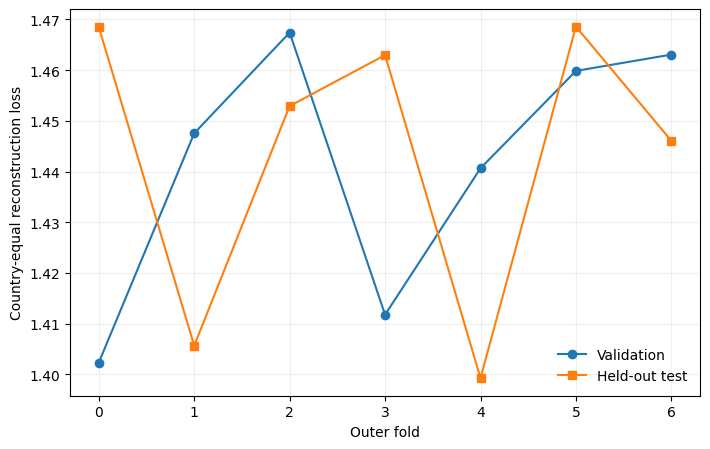

In [ ]:
# Figure: validation vs unseen TEST across seven folds

import matplotlib.pyplot as plt


fig, ax = plt.subplots(
    figsize=(
        7.2,
        4.6
    )
)


ax.plot(
    fold_audit[
        "outer_fold"
    ],
    fold_audit[
        "best_validation_reconstruction"
    ],
    marker="o",
    label="Validation"
)


ax.plot(
    fold_audit[
        "outer_fold"
    ],
    fold_audit[
        "country_equal_reconstruction"
    ],
    marker="s",
    label="Held-out test"
)


ax.set_xlabel(
    "Outer fold"
)

ax.set_ylabel(
    "Country-equal reconstruction loss"
)

ax.set_xticks(
    range(
        7
    )
)

ax.legend(
    frameon=False
)

ax.grid(
    alpha=0.2
)


fig.tight_layout()


fig.savefig(
    FIG_DIR
    / "crest_validation_vs_unseen_test.pdf",
    bbox_inches="tight"
)


fig.savefig(
    FIG_DIR
    / "crest_validation_vs_unseen_test.png",
    dpi=300,
    bbox_inches="tight"
)


plt.show()

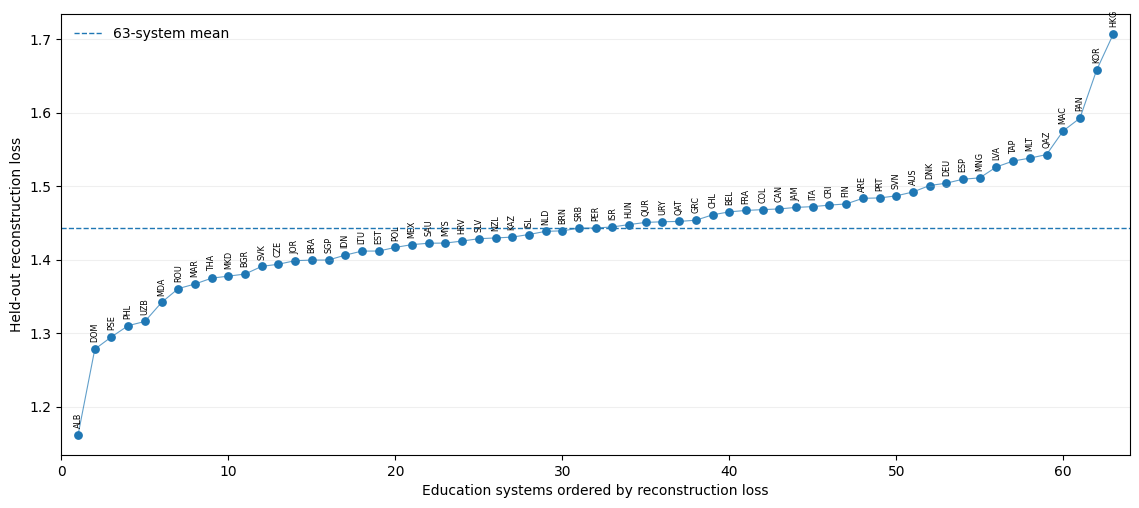

In [ ]:
# Figure: unseen reconstruction across all 63 systems

plot_df = (
    system_df
    .sort_values(
        "reconstruction"
    )
    .reset_index(
        drop=True
    )
)


fig, ax = plt.subplots(
    figsize=(
        11.5,
        5.2
    )
)


x_rank = np.arange(
    1,
    len(
        plot_df
    ) + 1
)


ax.scatter(
    x_rank,
    plot_df[
        "reconstruction"
    ],
    s=28
)


ax.plot(
    x_rank,
    plot_df[
        "reconstruction"
    ],
    linewidth=0.8,
    alpha=0.7
)


ax.axhline(
    plot_df[
        "reconstruction"
    ].mean(),
    linestyle="--",
    linewidth=1.0,
    label="63-system mean"
)


for i, row in (
    plot_df.iterrows()
):

    ax.annotate(
        row[
            "country"
        ],

        (
            i + 1,
            row[
                "reconstruction"
            ]
        ),

        xytext=(
            0,
            5
        ),

        textcoords="offset points",

        ha="center",
        va="bottom",

        fontsize=5.8,

        rotation=90
    )


ax.set_xlabel(
    "Education systems ordered by reconstruction loss"
)

ax.set_ylabel(
    "Held-out reconstruction loss"
)

ax.set_xlim(
    0,
    64
)

ax.legend(
    frameon=False
)

ax.grid(
    axis="y",
    alpha=0.2
)


fig.tight_layout()


fig.savefig(
    FIG_DIR
    / "crest_63system_unseen_generalization.pdf",
    bbox_inches="tight"
)


fig.savefig(
    FIG_DIR
    / "crest_63system_unseen_generalization.png",
    dpi=300,
    bbox_inches="tight"
)


plt.show()

In [ ]:
# Lock nuisance-probe protocol and extract validation latents

from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import RidgeClassifier
from sklearn.metrics import (
    accuracy_score,
    balanced_accuracy_score,
    f1_score
)

NUISANCE_PROTOCOL = {

    "status":
        "LOCKED",

    "probe_training_data":
        "validation systems only",

    "probe_evaluation_data":
        "held-out test systems only",

    "test_model_forward_pass":
        False,

    "probe":
        "StandardScaler + RidgeClassifier",

    "ridge_alpha":
        1.0,

    "ridge_solver":
        "lsqr",

    "class_weight":
        "balanced",

    "representations":
        [
            "z_general",
            "z_context",
            "design_mask_positive_control"
        ],

    "targets":
        [
            "booklet",
            "design_signature"
        ],

    "primary_metric":
        "balanced_accuracy"
}


with open(
    RESULTS_DIR
    / "crest_final_nuisance_probe_protocol.json",
    "w",
    encoding="utf-8"
) as f:

    json.dump(
        NUISANCE_PROTOCOL,
        f,
        indent=2
    )


@torch.inference_mode()
def extract_validation_probe_latents(
    model,
    dataset,
    batch_size=512
):

    model.eval()

    loader = DataLoader(
        dataset,
        batch_size=batch_size,
        shuffle=False,
        num_workers=0
    )

    z_general = []
    z_context = []

    for batch in loader:

        batch = {
            key: value.to(device)
            for key, value
            in batch.items()
        }

        output = model(
            batch,
            lambda_booklet_grl=0.0,
            lambda_design_grl=0.0,
            lambda_country_grl=0.0
        )

        z_general.append(
            output[
                "z_general"
            ].cpu().numpy()
        )

        z_context.append(
            output[
                "z_context"
            ].cpu().numpy()
        )

    return (
        np.concatenate(
            z_general,
            axis=0
        ).astype(
            np.float32
        ),

        np.concatenate(
            z_context,
            axis=0
        ).astype(
            np.float32
        )
    )


for outer_fold in range(7):

    save_path = (
        TEST_OUTPUT_ROOT
        / f"fold_{outer_fold}"
        / "validation_probe_latents.npz"
    )

    if save_path.exists():

        print(
            f"Fold {outer_fold}: "
            "validation latents already saved."
        )

        continue


    validation_fold = (
        outer_fold + 1
    ) % 7


    validation_idx = np.where(
        primary_meta[
            "country_fold"
        ].to_numpy()
        == validation_fold
    )[0]


    resources = (
        load_fold_resources(
            outer_fold
        )
    )


    validation_split = (
        make_eval_split_data(
            validation_idx,
            resources
        )
    )


    validation_dataset = (
        crest_core
        .CReSTFinalDataset(
            validation_split
        )
    )


    model, _ = (
        restore_final_model(
            outer_fold,
            resources
        )
    )


    start = time.perf_counter()


    (
        z_general_val,
        z_context_val
    ) = (
        extract_validation_probe_latents(
            model,
            validation_dataset,
            batch_size=512
        )
    )


    elapsed = (
        time.perf_counter()
        -
        start
    )


    np.savez_compressed(
        save_path,

        handoff_row_index=(
            validation_idx.astype(
                np.int64
            )
        ),

        z_general=(
            z_general_val
        ),

        z_context=(
            z_context_val
        )
    )


    print(
        f"Fold {outer_fold}: "
        f"{len(validation_idx):,} validation students, "
        f"{elapsed:.1f}s"
    )


    del model
    del resources
    del validation_dataset
    del validation_split

    gc.collect()


print(
    "\nValidation latent extraction complete."
)

print(
    "Held-out TEST models were NOT rerun."
)

Fold 0: 20,949 validation students, 25.6s
Fold 1: 20,769 validation students, 24.9s
Fold 2: 20,324 validation students, 24.5s
Fold 3: 19,460 validation students, 22.9s
Fold 4: 19,694 validation students, 24.5s
Fold 5: 19,719 validation students, 24.2s
Fold 6: 21,649 validation students, 27.1s

Validation latent extraction complete.
Held-out TEST models were NOT rerun.


In [ ]:
# Cross-system frozen nuisance probes

def make_linear_probe():

    return Pipeline(
        [
            (
                "scale",
                StandardScaler()
            ),
            (
                "ridge",
                RidgeClassifier(
                    alpha=1.0,
                    solver="lsqr",
                    class_weight="balanced"
                )
            )
        ]
    )


def probe_metrics(
    X_train,
    y_train,
    X_test,
    y_test
):

    probe = (
        make_linear_probe()
    )

    probe.fit(
        X_train,
        y_train
    )

    prediction = (
        probe.predict(
            X_test
        )
    )


    return {

        "accuracy":
            float(
                accuracy_score(
                    y_test,
                    prediction
                )
            ),

        "balanced_accuracy":
            float(
                balanced_accuracy_score(
                    y_test,
                    prediction
                )
            ),

        "macro_f1":
            float(
                f1_score(
                    y_test,
                    prediction,
                    average="macro",
                    zero_division=0
                )
            ),

        "n_train_classes":
            int(
                len(
                    np.unique(
                        y_train
                    )
                )
            ),

        "n_test_classes":
            int(
                len(
                    np.unique(
                        y_test
                    )
                )
            )
    }


probe_rows = []


for outer_fold in range(7):

    validation_latent_file = np.load(

        TEST_OUTPUT_ROOT
        / f"fold_{outer_fold}"
        / "validation_probe_latents.npz"
    )


    validation_idx = (
        validation_latent_file[
            "handoff_row_index"
        ]
    )


    test_idx = np.load(

        TEST_OUTPUT_ROOT
        / f"fold_{outer_fold}"
        / "handoff_row_index.npy"
    )


    # Representations

    representations = {

        "z_general": (

            validation_latent_file[
                "z_general"
            ],

            np.load(
                TEST_OUTPUT_ROOT
                / f"fold_{outer_fold}"
                / "z_general.npy"
            )
        ),

        "z_context": (

            validation_latent_file[
                "z_context"
            ],

            np.load(
                TEST_OUTPUT_ROOT
                / f"fold_{outer_fold}"
                / "z_context.npy"
            )
        ),

        "design_mask": (

            np.asarray(
                student_design_mask[
                    validation_idx
                ],
                dtype=np.float32
            ),

            np.asarray(
                student_design_mask[
                    test_idx
                ],
                dtype=np.float32
            )
        )
    }


    # Nuisance targets

    booklet_val = np.asarray(
        booklet_nuisance_ids[
            validation_idx
        ],
        dtype=np.int64
    )

    booklet_test = np.asarray(
        booklet_nuisance_ids[
            test_idx
        ],
        dtype=np.int64
    )


    design_val = (
        BOOKLET_TO_SIGNATURE[
            booklet_val
        ]
        .astype(
            np.int64
        )
    )

    design_test = (
        BOOKLET_TO_SIGNATURE[
            booklet_test
        ]
        .astype(
            np.int64
        )
    )


    targets = {

        "booklet": (
            booklet_val,
            booklet_test,
            1.0 / 30.0
        ),

        "design_signature": (
            design_val,
            design_test,
            1.0 / 10.0
        )
    }


    for representation_name, (
        X_val,
        X_test
    ) in representations.items():

        for target_name, (
            y_val,
            y_test,
            chance
        ) in targets.items():

            metrics = (
                probe_metrics(
                    X_val,
                    y_val,
                    X_test,
                    y_test
                )
            )


            probe_rows.append(
                {
                    "outer_fold":
                        outer_fold,

                    "representation":
                        representation_name,

                    "target":
                        target_name,

                    "chance_balanced_accuracy":
                        chance,

                    **metrics
                }
            )


            print(
                f"Fold {outer_fold} | "
                f"{representation_name:11s} | "
                f"{target_name:16s} | "
                f"BA={metrics['balanced_accuracy']:.4f} | "
                f"F1={metrics['macro_f1']:.4f}"
            )


probe_df = pd.DataFrame(
    probe_rows
)


probe_df.to_csv(
    RESULTS_DIR
    / "crest_final_crosssystem_nuisance_probes.csv",
    index=False
)


print(
    "\nCross-system nuisance probes complete."
)

Fold 0 | z_general   | booklet          | BA=0.0703 | F1=0.0244
Fold 0 | z_general   | design_signature | BA=0.2166 | F1=0.2017
Fold 0 | z_context   | booklet          | BA=0.0322 | F1=0.0077
Fold 0 | z_context   | design_signature | BA=0.0983 | F1=0.0969
Fold 0 | design_mask | booklet          | BA=0.3333 | F1=0.2008
Fold 0 | design_mask | design_signature | BA=1.0000 | F1=1.0000
Fold 1 | z_general   | booklet          | BA=0.0693 | F1=0.0323
Fold 1 | z_general   | design_signature | BA=0.2095 | F1=0.1928
Fold 1 | z_context   | booklet          | BA=0.0362 | F1=0.0093
Fold 1 | z_context   | design_signature | BA=0.0984 | F1=0.0955
Fold 1 | design_mask | booklet          | BA=0.3333 | F1=0.2021
Fold 1 | design_mask | design_signature | BA=1.0000 | F1=1.0000
Fold 2 | z_general   | booklet          | BA=0.0709 | F1=0.0247
Fold 2 | z_general   | design_signature | BA=0.2230 | F1=0.2153
Fold 2 | z_context   | booklet          | BA=0.0304 | F1=0.0071
Fold 2 | z_context   | design_signature 

In [ ]:
# Aggregate nuisance leakage across all seven folds

nuisance_summary = (

    probe_df

    .groupby(
        [
            "representation",
            "target"
        ],
        as_index=False
    )

    .agg(

        balanced_accuracy_mean=(
            "balanced_accuracy",
            "mean"
        ),

        balanced_accuracy_sd=(
            "balanced_accuracy",
            "std"
        ),

        macro_f1_mean=(
            "macro_f1",
            "mean"
        ),

        macro_f1_sd=(
            "macro_f1",
            "std"
        ),

        accuracy_mean=(
            "accuracy",
            "mean"
        ),

        chance=(
            "chance_balanced_accuracy",
            "first"
        )
    )
)


nuisance_summary[
    "absolute_excess_over_chance"
] = (

    nuisance_summary[
        "balanced_accuracy_mean"
    ]

    -

    nuisance_summary[
        "chance"
    ]
)


nuisance_summary[
    "normalized_excess_over_chance"
] = (

    nuisance_summary[
        "absolute_excess_over_chance"
    ]

    /

    (
        1.0
        -
        nuisance_summary[
            "chance"
        ]
    )
)


nuisance_summary.to_csv(

    RESULTS_DIR
    / "crest_final_crosssystem_nuisance_summary.csv",

    index=False
)


print(
    nuisance_summary[
        [
            "representation",
            "target",
            "balanced_accuracy_mean",
            "balanced_accuracy_sd",
            "chance",
            "absolute_excess_over_chance",
            "macro_f1_mean"
        ]
    ].to_string(
        index=False
    )
)

representation           target  balanced_accuracy_mean  balanced_accuracy_sd   chance  absolute_excess_over_chance  macro_f1_mean
   design_mask          booklet                0.333333              0.000000 0.033333                     0.300000       0.191084
   design_mask design_signature                1.000000              0.000000 0.100000                     0.900000       1.000000
     z_context          booklet                0.031781              0.002229 0.033333                    -0.001552       0.007522
     z_context design_signature                0.098533              0.001853 0.100000                    -0.001467       0.096523
     z_general          booklet                0.070407              0.006088 0.033333                     0.037074       0.030600
     z_general design_signature                0.223137              0.014553 0.100000                     0.123137       0.208630


In [ ]:
# Quantify nuisance suppression relative to positive control

summary = nuisance_summary.copy()

positive = (
    summary[
        summary["representation"]
        == "design_mask"
    ]
    .set_index("target")
)

general = (
    summary[
        summary["representation"]
        == "z_general"
    ]
    .set_index("target")
)


rows = []

for target in [
    "booklet",
    "design_signature"
]:

    chance = float(
        general.loc[
            target,
            "chance"
        ]
    )

    positive_ba = float(
        positive.loc[
            target,
            "balanced_accuracy_mean"
        ]
    )

    general_ba = float(
        general.loc[
            target,
            "balanced_accuracy_mean"
        ]
    )

    positive_excess = (
        positive_ba
        -
        chance
    )

    general_excess = (
        general_ba
        -
        chance
    )

    residual_fraction = (
        general_excess
        /
        positive_excess
    )

    suppression_fraction = (
        1.0
        -
        residual_fraction
    )


    rows.append(
        {
            "target":
                target,

            "chance":
                chance,

            "positive_control_ba":
                positive_ba,

            "z_general_ba":
                general_ba,

            "residual_fraction_of_design_signal":
                residual_fraction,

            "suppressed_fraction_of_design_signal":
                suppression_fraction
        }
    )


suppression_df = pd.DataFrame(
    rows
)


suppression_df[
    "suppressed_percent"
] = (
    100.0
    *
    suppression_df[
        "suppressed_fraction_of_design_signal"
    ]
)


suppression_df.to_csv(
    RESULTS_DIR
    / "crest_nuisance_suppression_effect_sizes.csv",
    index=False
)


print(
    suppression_df.to_string(
        index=False
    )
)

          target   chance  positive_control_ba  z_general_ba  residual_fraction_of_design_signal  suppressed_fraction_of_design_signal  suppressed_percent
         booklet 0.033333             0.333333      0.070407                            0.123580                              0.876420           87.641988
design_signature 0.100000             1.000000      0.223137                            0.136819                              0.863181           86.318095


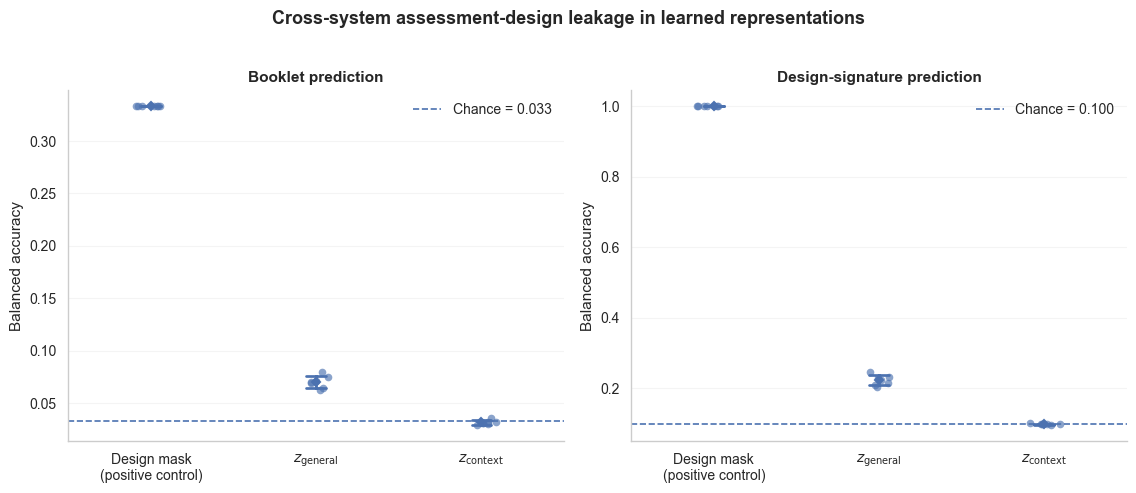

In [ ]:
# Publication-quality nuisance robustness figure

import matplotlib.pyplot as plt
import seaborn as sns


sns.set_theme(
    context="paper",
    style="whitegrid",
    font_scale=1.15
)


plot_df = probe_df.copy()


label_map = {
    "design_mask":
        "Design mask\n(positive control)",

    "z_general":
        r"$z_{\mathrm{general}}$",

    "z_context":
        r"$z_{\mathrm{context}}$"
}


target_map = {
    "booklet":
        "Booklet prediction",

    "design_signature":
        "Design-signature prediction"
}


plot_df[
    "Representation"
] = (
    plot_df[
        "representation"
    ]
    .map(
        label_map
    )
)


plot_df[
    "Target"
] = (
    plot_df[
        "target"
    ]
    .map(
        target_map
    )
)


order = [
    "Design mask\n(positive control)",
    r"$z_{\mathrm{general}}$",
    r"$z_{\mathrm{context}}$"
]


fig, axes = plt.subplots(
    1,
    2,
    figsize=(
        11.5,
        4.8
    ),
    sharey=False
)


for ax, target in zip(
    axes,
    [
        "booklet",
        "design_signature"
    ]
):

    sub = plot_df[
        plot_df[
            "target"
        ]
        == target
    ].copy()


    sns.stripplot(
        data=sub,
        x="Representation",
        y="balanced_accuracy",
        order=order,
        jitter=0.10,
        size=5.5,
        alpha=0.65,
        ax=ax
    )


    sns.pointplot(
        data=sub,
        x="Representation",
        y="balanced_accuracy",
        order=order,
        errorbar="sd",
        join=False,
        markers="D",
        scale=0.9,
        capsize=0.12,
        ax=ax
    )


    chance = (
        1.0 / 30.0
        if target == "booklet"
        else 0.10
    )


    ax.axhline(
        chance,
        linestyle="--",
        linewidth=1.2,
        label=f"Chance = {chance:.3f}"
    )


    ax.set_title(
        target_map[
            target
        ],
        fontweight="semibold"
    )

    ax.set_xlabel(
        ""
    )

    ax.set_ylabel(
        "Balanced accuracy"
    )

    ax.legend(
        frameon=False,
        loc="upper right"
    )

    ax.grid(
        axis="y",
        alpha=0.20
    )

    ax.grid(
        axis="x",
        visible=False
    )

    sns.despine(
        ax=ax
    )


fig.suptitle(
    "Cross-system assessment-design leakage in learned representations",
    fontsize=13,
    fontweight="semibold",
    y=1.02
)


fig.tight_layout()


fig.savefig(
    FIG_DIR
    / "crest_crosssystem_nuisance_robustness.pdf",
    bbox_inches="tight"
)


fig.savefig(
    FIG_DIR
    / "crest_crosssystem_nuisance_robustness.png",
    dpi=400,
    bbox_inches="tight"
)


plt.show()

In [ ]:
# Lock the 7-fold disjoint-item creative-signal safeguard

from scipy.stats import spearmanr

from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import Ridge
from sklearn.metrics import (
    r2_score,
    mean_absolute_error
)


ITEM_SPLIT_SEED = 20261005


ITEM_SET_A = np.array(
    [
        0, 1, 5, 6, 7, 8, 9, 10,
        12, 15, 17, 20, 24, 27, 28, 31
    ],
    dtype=np.int64
)


ITEM_SET_B = np.array(
    [
        2, 3, 4, 11, 13, 14, 16, 18,
        19, 21, 22, 23, 25, 26, 29, 30
    ],
    dtype=np.int64
)


assert len(
    np.intersect1d(
        ITEM_SET_A,
        ITEM_SET_B
    )
) == 0


assert np.array_equal(
    np.sort(
        np.concatenate(
            [
                ITEM_SET_A,
                ITEM_SET_B
            ]
        )
    ),
    np.arange(
        32
    )
)


CREATIVE_SIGNAL_PROTOCOL = {

    "status":
        "LOCKED",

    "item_split_seed":
        ITEM_SPLIT_SEED,

    "item_set_A":
        ITEM_SET_A.tolist(),

    "item_set_B":
        ITEM_SET_B.tolist(),

    "directions":
        [
            "A_to_B",
            "B_to_A"
        ],

    "latent":
        "z_general",

    "target":
        "mean normalized credit over hidden target items",

    "credit_normalization":
        "NO=0, PARTIAL=0.5, FULL=1",

    "minimum_target_scorable_items":
        1,

    "minimum_source_interaction_items":
        1,

    "probe_training":
        "validation systems only",

    "probe_evaluation":
        "held-out TEST systems only",

    "probe":
        "StandardScaler + Ridge(alpha=1.0)",

    "target_items_hidden_from_latent":
        True,

    "hidden_modalities":
        [
            "credit",
            "behaviour",
            "process",
            "interaction mask",
            "performance mask",
            "design mask at hidden items"
        ],

    "deep_model_updated":
        False,

    "primary_metrics":
        [
            "R2",
            "MAE",
            "Spearman rho"
        ]
}


with open(
    RESULTS_DIR
    / "crest_creative_signal_safeguard_protocol.json",
    "w",
    encoding="utf-8"
) as f:

    json.dump(
        CREATIVE_SIGNAL_PROTOCOL,
        f,
        indent=2
    )


print(
    "Creative-signal safeguard protocol: LOCKED"
)

print(
    "Set A:",
    ITEM_SET_A.tolist()
)

print(
    "Set B:",
    ITEM_SET_B.tolist()
)

print(
    "\nTarget items will be completely hidden "
    "before z_general is produced."
)

Creative-signal safeguard protocol: LOCKED
Set A: [0, 1, 5, 6, 7, 8, 9, 10, 12, 15, 17, 20, 24, 27, 28, 31]
Set B: [2, 3, 4, 11, 13, 14, 16, 18, 19, 21, 22, 23, 25, 26, 29, 30]

Target items will be completely hidden before z_general is produced.


In [ ]:
# Efficient disjoint-item creative-signal helpers

def hide_target_items(
    split_data,
    hidden_items
):

    d = split_data.copy()


    for key in [
        "credit_tokens",
        "behaviour_tokens",
        "performance_mask",
        "interaction_mask",
        "design_mask",
        "process_raw",
        "process_values",
        "process_mask"
    ]:

        d[key] = (
            split_data[
                key
            ].copy()
        )


    d[
        "credit_tokens"
    ][
        :,
        hidden_items
    ] = 0


    d[
        "behaviour_tokens"
    ][
        :,
        hidden_items
    ] = 0


    d[
        "performance_mask"
    ][
        :,
        hidden_items
    ] = False


    d[
        "interaction_mask"
    ][
        :,
        hidden_items
    ] = False


    d[
        "design_mask"
    ][
        :,
        hidden_items
    ] = False


    d[
        "process_raw"
    ][
        :,
        hidden_items,
        :
    ] = 0.0


    d[
        "process_values"
    ][
        :,
        hidden_items,
        :
    ] = 0.0


    d[
        "process_mask"
    ][
        :,
        hidden_items,
        :
    ] = False


    return d


def observed_credit_target(
    split_data,
    target_items
):

    tokens = (
        split_data[
            "credit_tokens"
        ][
            :,
            target_items
        ]
    )


    mask = (
        split_data[
            "performance_mask"
        ][
            :,
            target_items
        ]
        &
        (tokens >= 1)
        &
        (tokens <= 3)
    )


    # NO=0, PARTIAL=.5, FULL=1
    score = (
        tokens.astype(
            np.float32
        )
        -
        1.0
    ) / 2.0


    score = np.where(
        mask,
        score,
        0.0
    )


    count = mask.sum(
        axis=1
    )


    mean_score = np.divide(

        score.sum(
            axis=1
        ),

        count,

        out=np.full(
            len(score),
            np.nan,
            dtype=np.float32
        ),

        where=(
            count > 0
        )
    )


    return (
        mean_score,
        count
    )


@torch.inference_mode()
def extract_z_general_only(
    model,
    dataset,
    batch_size=1024
):

    model.eval()


    loader = DataLoader(

        dataset,

        batch_size=batch_size,

        shuffle=False,

        num_workers=0
    )


    latent_rows = []


    for batch in loader:

        batch = {
            key:
                value.to(
                    device
                )

            for key, value
            in batch.items()
        }


        (
            calibrated_tokens,
            general_available
        ) = (
            model.general_builder(
                batch
            )
        )


        general_tokens = (
            model.general_token_projection(
                calibrated_tokens
            )
        )


        process_ids = torch.arange(
            model.n_processes,
            device=device
        )


        general_tokens = (
            general_tokens
            +
            model.ideation_embedding(
                process_ids
            ).unsqueeze(0)
        )


        safe_available = (
            general_available.clone()
        )


        no_general = (
            ~safe_available.any(
                dim=1
            )
        )


        if no_general.any():

            safe_available[
                no_general,
                0
            ] = True

            general_tokens = (
                general_tokens.clone()
            )

            general_tokens[
                no_general,
                0,
                :
            ] = 0.0


        encoded = (
            model.general_process_encoder(

                general_tokens,

                src_key_padding_mask=(
                    ~safe_available
                )
            )
        )


        weights = (
            general_available
            .float()
            .unsqueeze(-1)
        )


        pooled = (

            (
                encoded
                *
                weights
            )
            .sum(
                dim=1
            )

            /

            weights.sum(
                dim=1
            )
            .clamp_min(
                1.0
            )
        )


        z_general = (
            model.creative_projection(

                model.general_pool_norm(
                    pooled
                )
            )
        )


        latent_rows.append(
            z_general.cpu()
            .numpy()
            .astype(
                np.float32
            )
        )


    return np.concatenate(
        latent_rows,
        axis=0
    )


def make_signal_probe():

    return Pipeline(
        [
            (
                "scale",
                StandardScaler()
            ),
            (
                "ridge",
                Ridge(
                    alpha=1.0
                )
            )
        ]
    )


def safe_spearman(
    y_true,
    y_pred
):

    result = spearmanr(
        y_true,
        y_pred
    )

    return float(
        result.statistic
    )


def regression_metrics(
    y_true,
    y_pred
):

    return {

        "r2":
            float(
                r2_score(
                    y_true,
                    y_pred
                )
            ),

        "mae":
            float(
                mean_absolute_error(
                    y_true,
                    y_pred
                )
            ),

        "rho":
            safe_spearman(
                y_true,
                y_pred
            )
    }


print(
    "Disjoint-item safeguard helpers ready."
)

Disjoint-item safeguard helpers ready.


In [ ]:
# Seven-fold unseen-system creative-signal retention

signal_fold_rows = []
signal_country_rows = []


direction_specs = {

    "A_to_B": (
        ITEM_SET_A,
        ITEM_SET_B
    ),

    "B_to_A": (
        ITEM_SET_B,
        ITEM_SET_A
    )
}


SIGNAL_OUTPUT_DIR = (
    RESULTS_DIR
    / "creative_signal_safeguard"
)

SIGNAL_OUTPUT_DIR.mkdir(
    parents=True,
    exist_ok=True
)


for outer_fold in range(
    7
):

    print(
        "\n"
        + "=" * 72
    )

    print(
        f"CREATIVE-SIGNAL SAFEGUARD — FOLD {outer_fold}"
    )

    print(
        "=" * 72
    )


    resources = (
        load_fold_resources(
            outer_fold
        )
    )


    model, _ = (
        restore_final_model(
            outer_fold,
            resources
        )
    )


    validation_fold = (
        outer_fold + 1
    ) % 7


    validation_idx = np.where(
        primary_meta[
            "country_fold"
        ].to_numpy()
        == validation_fold
    )[0]


    test_idx = np.load(

        FINAL_TEST_ROOT
        / f"fold_{outer_fold}"
        / "test_indices.npy"
    )


    validation_split = (
        make_eval_split_data(
            validation_idx,
            resources
        )
    )


    test_split = (
        make_eval_split_data(
            test_idx,
            resources
        )
    )


    for (
        direction,
        (
            source_items,
            target_items
        )
    ) in direction_specs.items():


        # Targets are measured BEFORE hiding target items.

        (
            y_val,
            target_count_val
        ) = observed_credit_target(
            validation_split,
            target_items
        )


        (
            y_test,
            target_count_test
        ) = observed_credit_target(
            test_split,
            target_items
        )


        source_count_val = (

            validation_split[
                "interaction_mask"
            ][
                :,
                source_items
            ]
            .sum(
                axis=1
            )
        )


        source_count_test = (

            test_split[
                "interaction_mask"
            ][
                :,
                source_items
            ]
            .sum(
                axis=1
            )
        )


        valid_val = (
            np.isfinite(
                y_val
            )
            &
            (
                target_count_val
                >= 1
            )
            &
            (
                source_count_val
                >= 1
            )
        )


        valid_test = (
            np.isfinite(
                y_test
            )
            &
            (
                target_count_test
                >= 1
            )
            &
            (
                source_count_test
                >= 1
            )
        )


        # Completely hide target items from z_general.

        validation_hidden = (
            hide_target_items(
                validation_split,
                target_items
            )
        )


        test_hidden = (
            hide_target_items(
                test_split,
                target_items
            )
        )


        validation_dataset = (
            crest_core
            .CReSTFinalDataset(
                validation_hidden
            )
        )


        test_dataset = (
            crest_core
            .CReSTFinalDataset(
                test_hidden
            )
        )


        start = time.perf_counter()


        z_val = (
            extract_z_general_only(
                model,
                validation_dataset,
                batch_size=1024
            )
        )


        z_test = (
            extract_z_general_only(
                model,
                test_dataset,
                batch_size=1024
            )
        )


        elapsed = (
            time.perf_counter()
            -
            start
        )


        # Probe trained only on validation systems.

        probe = (
            make_signal_probe()
        )


        probe.fit(
            z_val[
                valid_val
            ],
            y_val[
                valid_val
            ]
        )


        prediction = (
            probe.predict(
                z_test[
                    valid_test
                ]
            )
        )


        pooled = (
            regression_metrics(

                y_test[
                    valid_test
                ],

                prediction
            )
        )


        # Country-level unseen-system performance

        test_countries = (
            test_split[
                "CNT"
            ][
                valid_test
            ]
        )


        true_valid = (
            y_test[
                valid_test
            ]
        )


        country_metric_rows_local = []


        for country in sorted(
            np.unique(
                test_countries
            )
        ):

            m = (
                test_countries
                == country
            )


            metrics = (
                regression_metrics(
                    true_valid[m],
                    prediction[m]
                )
            )


            row = {

                "outer_fold":
                    outer_fold,

                "direction":
                    direction,

                "country":
                    country,

                "n_students":
                    int(
                        m.sum()
                    ),

                **metrics
            }


            signal_country_rows.append(
                row
            )

            country_metric_rows_local.append(
                row
            )


        country_local_df = pd.DataFrame(
            country_metric_rows_local
        )


        country_equal = {

            "country_equal_r2":
                float(
                    country_local_df[
                        "r2"
                    ].mean()
                ),

            "country_equal_mae":
                float(
                    country_local_df[
                        "mae"
                    ].mean()
                ),

            "country_equal_rho":
                float(
                    country_local_df[
                        "rho"
                    ].mean()
                )
        }


        fold_row = {

            "outer_fold":
                outer_fold,

            "direction":
                direction,

            "n_validation_students":
                int(
                    valid_val.sum()
                ),

            "n_test_students":
                int(
                    valid_test.sum()
                ),

            "pooled_r2":
                pooled[
                    "r2"
                ],

            "pooled_mae":
                pooled[
                    "mae"
                ],

            "pooled_rho":
                pooled[
                    "rho"
                ],

            **country_equal,

            "latent_seconds":
                float(
                    elapsed
                )
        }


        signal_fold_rows.append(
            fold_row
        )


        # Preserve predictions for later diagnostics.
        np.savez_compressed(

            SIGNAL_OUTPUT_DIR
            / (
                f"fold_{outer_fold}_"
                f"{direction}_test_predictions.npz"
            ),

            handoff_row_index=(
                test_idx[
                    valid_test
                ]
            ),

            target=(
                true_valid.astype(
                    np.float32
                )
            ),

            prediction=(
                prediction.astype(
                    np.float32
                )
            ),

            target_item_count=(
                target_count_test[
                    valid_test
                ].astype(
                    np.int8
                )
            )
        )


        print(
            f"{direction:6s} | "
            f"N={valid_test.sum():,} | "
            f"R2={pooled['r2']:.4f} | "
            f"MAE={pooled['mae']:.4f} | "
            f"rho={pooled['rho']:.4f} | "
            f"country-rho={country_equal['country_equal_rho']:.4f}"
        )


        del validation_dataset
        del test_dataset
        del validation_hidden
        del test_hidden
        del z_val
        del z_test
        del probe

        gc.collect()


    del model
    del resources
    del validation_split
    del test_split

    gc.collect()


signal_fold_df = pd.DataFrame(
    signal_fold_rows
)


signal_country_df = pd.DataFrame(
    signal_country_rows
)


signal_fold_df.to_csv(

    RESULTS_DIR
    / "crest_final_7fold_creative_signal.csv",

    index=False
)


signal_country_df.to_csv(

    RESULTS_DIR
    / "crest_final_63system_creative_signal.csv",

    index=False
)


print(
    "\nCreative-signal safeguard complete."
)


CREATIVE-SIGNAL SAFEGUARD — FOLD 0
A_to_B | N=21,537 | R2=0.2458 | MAE=0.1758 | rho=0.5334 | country-rho=0.5192
B_to_A | N=21,541 | R2=0.2714 | MAE=0.1623 | rho=0.5401 | country-rho=0.5275

CREATIVE-SIGNAL SAFEGUARD — FOLD 1
A_to_B | N=20,694 | R2=0.3587 | MAE=0.1826 | rho=0.6401 | country-rho=0.5044
B_to_A | N=20,715 | R2=0.3811 | MAE=0.1733 | rho=0.6664 | country-rho=0.5434

CREATIVE-SIGNAL SAFEGUARD — FOLD 2
A_to_B | N=20,611 | R2=0.3266 | MAE=0.1732 | rho=0.5656 | country-rho=0.5252
B_to_A | N=20,639 | R2=0.3157 | MAE=0.1663 | rho=0.5772 | country-rho=0.5418

CREATIVE-SIGNAL SAFEGUARD — FOLD 3
A_to_B | N=20,217 | R2=0.0701 | MAE=0.1982 | rho=0.4484 | country-rho=0.4421
B_to_A | N=20,255 | R2=0.0808 | MAE=0.1877 | rho=0.4551 | country-rho=0.4660

CREATIVE-SIGNAL SAFEGUARD — FOLD 4
A_to_B | N=19,355 | R2=0.3330 | MAE=0.1786 | rho=0.5923 | country-rho=0.5127
B_to_A | N=19,352 | R2=0.3396 | MAE=0.1698 | rho=0.6179 | country-rho=0.5354

CREATIVE-SIGNAL SAFEGUARD — FOLD 5
A_to_B | N=19,

In [ ]:
# Aggregate creative-signal retention

direction_summary = (

    signal_fold_df

    .groupby(
        "direction",
        as_index=False
    )

    .agg(

        pooled_r2_mean=(
            "pooled_r2",
            "mean"
        ),

        pooled_r2_sd=(
            "pooled_r2",
            "std"
        ),

        pooled_mae_mean=(
            "pooled_mae",
            "mean"
        ),

        pooled_mae_sd=(
            "pooled_mae",
            "std"
        ),

        pooled_rho_mean=(
            "pooled_rho",
            "mean"
        ),

        pooled_rho_sd=(
            "pooled_rho",
            "std"
        ),

        country_equal_r2_mean=(
            "country_equal_r2",
            "mean"
        ),

        country_equal_mae_mean=(
            "country_equal_mae",
            "mean"
        ),

        country_equal_rho_mean=(
            "country_equal_rho",
            "mean"
        )
    )
)


overall_summary = {

    "mean_pooled_r2":
        float(
            signal_fold_df[
                "pooled_r2"
            ].mean()
        ),

    "mean_pooled_mae":
        float(
            signal_fold_df[
                "pooled_mae"
            ].mean()
        ),

    "mean_pooled_rho":
        float(
            signal_fold_df[
                "pooled_rho"
            ].mean()
        ),

    "mean_country_equal_r2":
        float(
            signal_country_df[
                "r2"
            ].mean()
        ),

    "mean_country_equal_mae":
        float(
            signal_country_df[
                "mae"
            ].mean()
        ),

    "mean_country_equal_rho":
        float(
            signal_country_df[
                "rho"
            ].mean()
        ),

    "n_country_direction_evaluations":
        int(
            len(
                signal_country_df
            )
        )
}


direction_summary.to_csv(

    RESULTS_DIR
    / "crest_creative_signal_direction_summary.csv",

    index=False
)


with open(
    RESULTS_DIR
    / "crest_creative_signal_overall_summary.json",
    "w",
    encoding="utf-8"
) as f:

    json.dump(
        overall_summary,
        f,
        indent=2
    )


print(
    "DIRECTION-LEVEL SUMMARY"
)

print(
    "=" * 78
)

print(
    direction_summary.to_string(
        index=False
    )
)


print(
    "\nOVERALL"
)

print(
    "=" * 78
)

for key, value in (
    overall_summary.items()
):

    if isinstance(
        value,
        float
    ):

        print(
            f"{key:>38}: "
            f"{value:.6f}"
        )

    else:

        print(
            f"{key:>38}: "
            f"{value}"
        )

DIRECTION-LEVEL SUMMARY
direction  pooled_r2_mean  pooled_r2_sd  pooled_mae_mean  pooled_mae_sd  pooled_rho_mean  pooled_rho_sd  country_equal_r2_mean  country_equal_mae_mean  country_equal_rho_mean
   A_to_B        0.288224      0.104998         0.181156       0.008276         0.563257       0.062243                0.11267                0.184724                0.504627
   B_to_A        0.300370      0.104014         0.171664       0.008682         0.579082       0.067904                0.10400                0.174618                0.525290

OVERALL
                        mean_pooled_r2: 0.294297
                       mean_pooled_mae: 0.176410
                       mean_pooled_rho: 0.571170
                 mean_country_equal_r2: 0.108335
                mean_country_equal_mae: 0.179671
                mean_country_equal_rho: 0.514958
       n_country_direction_evaluations: 126


In [ ]:
# System-level creative-signal audit and Fold-3 diagnosis

signal_country_df = pd.read_csv(
    RESULTS_DIR
    / "crest_final_63system_creative_signal.csv"
)

assert (
    signal_country_df[
        "country"
    ].nunique()
    == 63
)

assert (
    len(
        signal_country_df
    )
    == 126
)


# Average A->B and B->A within each education system

system_signal = (

    signal_country_df

    .groupby(
        [
            "country",
            "outer_fold"
        ],
        as_index=False
    )

    .agg(

        n_students_mean=(
            "n_students",
            "mean"
        ),

        r2_mean=(
            "r2",
            "mean"
        ),

        mae_mean=(
            "mae",
            "mean"
        ),

        rho_mean=(
            "rho",
            "mean"
        ),

        r2_min=(
            "r2",
            "min"
        ),

        rho_min=(
            "rho",
            "min"
        )
    )
)


system_signal.to_csv(
    RESULTS_DIR
    / "crest_final_63system_creative_signal_summary.csv",
    index=False
)


print(
    "63-SYSTEM CREATIVE-SIGNAL SUMMARY"
)

print(
    "=" * 60
)

print(
    "Mean system R2:",
    f"{system_signal['r2_mean'].mean():.4f}"
)

print(
    "Median system R2:",
    f"{system_signal['r2_mean'].median():.4f}"
)

print(
    "Mean system rho:",
    f"{system_signal['rho_mean'].mean():.4f}"
)

print(
    "Median system rho:",
    f"{system_signal['rho_mean'].median():.4f}"
)

print(
    "Systems with mean R2 > 0:",
    int(
        (
            system_signal[
                "r2_mean"
            ]
            > 0
        ).sum()
    ),
    "/ 63"
)

print(
    "Systems with mean rho > 0.40:",
    int(
        (
            system_signal[
                "rho_mean"
            ]
            > 0.40
        ).sum()
    ),
    "/ 63"
)


print(
    "\nLowest 8 systems by mean rho:"
)

print(
    system_signal
    .sort_values(
        "rho_mean"
    )
    .head(
        8
    )[
        [
            "country",
            "outer_fold",
            "r2_mean",
            "mae_mean",
            "rho_mean"
        ]
    ]
    .to_string(
        index=False
    )
)


print(
    "\nHighest 8 systems by mean rho:"
)

print(
    system_signal
    .sort_values(
        "rho_mean",
        ascending=False
    )
    .head(
        8
    )[
        [
            "country",
            "outer_fold",
            "r2_mean",
            "mae_mean",
            "rho_mean"
        ]
    ]
    .to_string(
        index=False
    )
)


print(
    "\nFOLD 3 SYSTEMS"
)

print(
    "=" * 60
)

print(
    system_signal[
        system_signal[
            "outer_fold"
        ]
        == 3
    ][
        [
            "country",
            "r2_mean",
            "mae_mean",
            "rho_mean",
            "n_students_mean"
        ]
    ]
    .sort_values(
        "rho_mean"
    )
    .to_string(
        index=False
    )
)

63-SYSTEM CREATIVE-SIGNAL SUMMARY
Mean system R2: 0.1083
Median system R2: 0.2277
Mean system rho: 0.5150
Median system rho: 0.5132
Systems with mean R2 > 0: 55 / 63
Systems with mean rho > 0.40: 59 / 63

Lowest 8 systems by mean rho:
country  outer_fold   r2_mean  mae_mean  rho_mean
    TAP           3 -2.453057  0.406177  0.156090
    MAC           3 -1.314195  0.310289  0.273274
    UZB           1 -0.179723  0.188624  0.362188
    LVA           5  0.055574  0.166972  0.371303
    HKG           2  0.147368  0.178371  0.400519
    EST           0 -0.003971  0.172788  0.437901
    ESP           0  0.159361  0.165962  0.439905
    QAZ           5  0.164834  0.187277  0.445813

Highest 8 systems by mean rho:
country  outer_fold  r2_mean  mae_mean  rho_mean
    ARE           1 0.442828  0.167761  0.679317
    QAT           4 0.437194  0.167397  0.676361
    PHL           5 0.147495  0.189624  0.640989
    MKD           1 0.262915  0.181089  0.634169
    NLD           0 0.316494  0.161203

In [ ]:
# Cluster bootstrap confidence intervals across education systems

BOOTSTRAP_SEED = 20261006
N_BOOTSTRAP = 10000

rng = np.random.default_rng(
    BOOTSTRAP_SEED
)


system_ids = (
    system_signal[
        "country"
    ]
    .to_numpy()
)


bootstrap_rows = []


for _ in range(
    N_BOOTSTRAP
):

    sampled_systems = rng.choice(
        system_ids,
        size=len(
            system_ids
        ),
        replace=True
    )


    sampled_parts = []


    for system in sampled_systems:

        sampled_parts.append(

            system_signal[
                system_signal[
                    "country"
                ]
                == system
            ]
        )


    sample = pd.concat(
        sampled_parts,
        ignore_index=True
    )


    bootstrap_rows.append(
        [
            sample[
                "r2_mean"
            ].mean(),

            sample[
                "mae_mean"
            ].mean(),

            sample[
                "rho_mean"
            ].mean()
        ]
    )


bootstrap_array = np.asarray(
    bootstrap_rows
)


bootstrap_summary = pd.DataFrame(
    {
        "metric":
            [
                "R2",
                "MAE",
                "Spearman_rho"
            ],

        "estimate":
            [
                system_signal[
                    "r2_mean"
                ].mean(),

                system_signal[
                    "mae_mean"
                ].mean(),

                system_signal[
                    "rho_mean"
                ].mean()
            ],

        "ci_2.5":
            np.quantile(
                bootstrap_array,
                0.025,
                axis=0
            ),

        "ci_97.5":
            np.quantile(
                bootstrap_array,
                0.975,
                axis=0
            )
    }
)


bootstrap_summary.to_csv(
    RESULTS_DIR
    / "crest_creative_signal_system_bootstrap_ci.csv",
    index=False
)


print(
    bootstrap_summary.to_string(
        index=False
    )
)

      metric  estimate    ci_2.5  ci_97.5
          R2  0.108335 -0.013182 0.204876
         MAE  0.179671  0.171760 0.189962
Spearman_rho  0.514958  0.492707 0.535530


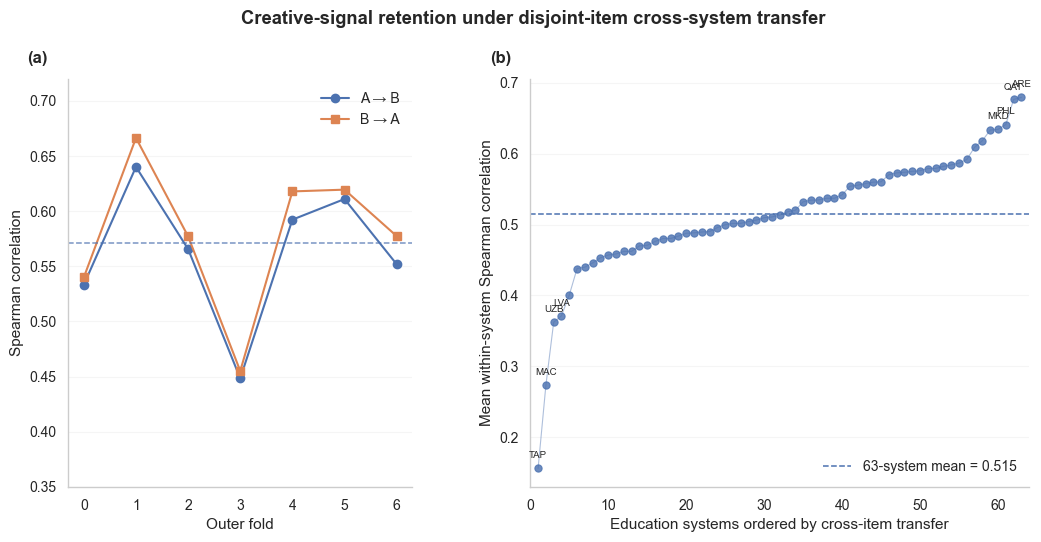

In [ ]:
# Publication figure: cross-system creative-signal retention

import matplotlib.pyplot as plt
from matplotlib.lines import Line2D


plot_fold = (
    signal_fold_df.copy()
)

plot_system = (
    system_signal
    .sort_values(
        "rho_mean"
    )
    .reset_index(
        drop=True
    )
)


fig = plt.figure(
    figsize=(
        12.4,
        5.3
    )
)


gs = fig.add_gridspec(
    1,
    2,
    width_ratios=[
        1.0,
        1.45
    ],
    wspace=0.28
)


# Panel A — fold-level transfer

ax1 = fig.add_subplot(
    gs[
        0,
        0
    ]
)


directions = [
    "A_to_B",
    "B_to_A"
]

markers = [
    "o",
    "s"
]


for direction, marker in zip(
    directions,
    markers
):

    sub = (
        plot_fold[
            plot_fold[
                "direction"
            ]
            == direction
        ]
        .sort_values(
            "outer_fold"
        )
    )


    label = (
        "A → B"
        if direction
        == "A_to_B"
        else "B → A"
    )


    ax1.plot(
        sub[
            "outer_fold"
        ],
        sub[
            "pooled_rho"
        ],
        marker=marker,
        markersize=6,
        linewidth=1.5,
        label=label
    )


ax1.axhline(
    signal_fold_df[
        "pooled_rho"
    ].mean(),
    linestyle="--",
    linewidth=1.1,
    alpha=0.75
)


ax1.set_xlabel(
    "Outer fold"
)

ax1.set_ylabel(
    "Spearman correlation"
)

ax1.set_xticks(
    np.arange(
        7
    )
)

ax1.set_ylim(
    0.35,
    0.72
)

ax1.legend(
    frameon=False,
    loc="upper right"
)

ax1.grid(
    axis="y",
    alpha=0.18
)

ax1.grid(
    axis="x",
    visible=False
)

ax1.spines[
    "top"
].set_visible(
    False
)

ax1.spines[
    "right"
].set_visible(
    False
)

ax1.text(
    -0.12,
    1.04,
    "(a)",
    transform=ax1.transAxes,
    fontsize=12,
    fontweight="semibold"
)


# Panel B — system-level transfer

ax2 = fig.add_subplot(
    gs[
        0,
        1
    ]
)


rank = np.arange(
    1,
    len(
        plot_system
    ) + 1
)


ax2.scatter(
    rank,
    plot_system[
        "rho_mean"
    ],
    s=27,
    alpha=0.82
)


ax2.plot(
    rank,
    plot_system[
        "rho_mean"
    ],
    linewidth=0.8,
    alpha=0.45
)


overall_rho = float(
    plot_system[
        "rho_mean"
    ].mean()
)


ax2.axhline(
    overall_rho,
    linestyle="--",
    linewidth=1.1,
    label=(
        f"63-system mean = "
        f"{overall_rho:.3f}"
    )
)


# Annotate only extremes for readability.
annotation_idx = (
    list(
        range(
            4
        )
    )
    +
    list(
        range(
            len(
                plot_system
            ) - 4,
            len(
                plot_system
            )
        )
    )
)


for i in annotation_idx:

    row = (
        plot_system.iloc[
            i
        ]
    )

    ax2.annotate(
        row[
            "country"
        ],
        (
            i + 1,
            row[
                "rho_mean"
            ]
        ),
        xytext=(
            0,
            6
        ),
        textcoords="offset points",
        ha="center",
        va="bottom",
        fontsize=7
    )


ax2.set_xlabel(
    "Education systems ordered by cross-item transfer"
)

ax2.set_ylabel(
    "Mean within-system Spearman correlation"
)

ax2.set_xlim(
    0,
    64
)

ax2.legend(
    frameon=False,
    loc="lower right"
)

ax2.grid(
    axis="y",
    alpha=0.18
)

ax2.grid(
    axis="x",
    visible=False
)

ax2.spines[
    "top"
].set_visible(
    False
)

ax2.spines[
    "right"
].set_visible(
    False
)

ax2.text(
    -0.08,
    1.04,
    "(b)",
    transform=ax2.transAxes,
    fontsize=12,
    fontweight="semibold"
)


fig.suptitle(
    "Creative-signal retention under disjoint-item "
    "cross-system transfer",
    fontsize=13.2,
    fontweight="semibold",
    y=1.01
)


fig.tight_layout()


fig.savefig(
    FIG_DIR
    / "crest_creative_signal_crosssystem_transfer.pdf",
    bbox_inches="tight"
)


fig.savefig(
    FIG_DIR
    / "crest_creative_signal_crosssystem_transfer.png",
    dpi=400,
    bbox_inches="tight"
)


plt.show()

In [ ]:
# Influence and robustness audit for creative-signal transfer

from scipy.stats import trim_mean


system_signal = pd.read_csv(
    RESULTS_DIR
    / "crest_final_63system_creative_signal_summary.csv"
)


# Robust descriptive summaries

robust_summary = pd.DataFrame(
    {
        "metric": [
            "R2",
            "MAE",
            "Spearman_rho"
        ],

        "mean": [
            system_signal["r2_mean"].mean(),
            system_signal["mae_mean"].mean(),
            system_signal["rho_mean"].mean()
        ],

        "median": [
            system_signal["r2_mean"].median(),
            system_signal["mae_mean"].median(),
            system_signal["rho_mean"].median()
        ],

        "trimmed_mean_10pct": [
            trim_mean(
                system_signal["r2_mean"],
                0.10
            ),

            trim_mean(
                system_signal["mae_mean"],
                0.10
            ),

            trim_mean(
                system_signal["rho_mean"],
                0.10
            )
        ]
    }
)


# Leave-one-system-out influence

influence_rows = []


for country in system_signal[
    "country"
]:

    remaining = (
        system_signal[
            system_signal[
                "country"
            ]
            != country
        ]
    )


    influence_rows.append(
        {
            "country":
                country,

            "r2_mean_without_system":
                remaining[
                    "r2_mean"
                ].mean(),

            "rho_mean_without_system":
                remaining[
                    "rho_mean"
                ].mean(),

            "r2_influence":
                (
                    remaining[
                        "r2_mean"
                    ].mean()
                    -
                    system_signal[
                        "r2_mean"
                    ].mean()
                ),

            "rho_influence":
                (
                    remaining[
                        "rho_mean"
                    ].mean()
                    -
                    system_signal[
                        "rho_mean"
                    ].mean()
                )
        }
    )


influence_df = pd.DataFrame(
    influence_rows
)


influence_df.to_csv(
    RESULTS_DIR
    / "crest_creative_signal_system_influence.csv",
    index=False
)


# Pure sensitivity diagnostic: TAP + MAC excluded
# NOT a replacement for the primary 63-system estimate.

without_tap_mac = (
    system_signal[
        ~system_signal[
            "country"
        ].isin(
            [
                "TAP",
                "MAC"
            ]
        )
    ]
)


sensitivity_tap_mac = {

    "n_systems":
        int(
            len(
                without_tap_mac
            )
        ),

    "r2_mean":
        float(
            without_tap_mac[
                "r2_mean"
            ].mean()
        ),

    "mae_mean":
        float(
            without_tap_mac[
                "mae_mean"
            ].mean()
        ),

    "rho_mean":
        float(
            without_tap_mac[
                "rho_mean"
            ].mean()
        )
}


print(
    "ROBUST DESCRIPTIVE SUMMARY"
)

print(
    "=" * 65
)

print(
    robust_summary.to_string(
        index=False
    )
)


print(
    "\nLargest positive influence on mean R2 "
    "when removed:"
)

print(
    influence_df
    .sort_values(
        "r2_influence",
        ascending=False
    )
    .head(
        8
    )
    .to_string(
        index=False
    )
)


print(
    "\nSensitivity only — excluding TAP and MAC:"
)

for key, value in (
    sensitivity_tap_mac.items()
):

    if isinstance(
        value,
        float
    ):

        print(
            f"{key:>12}: {value:.6f}"
        )

    else:

        print(
            f"{key:>12}: {value}"
        )


robust_summary.to_csv(
    RESULTS_DIR
    / "crest_creative_signal_robust_summary.csv",
    index=False
)

ROBUST DESCRIPTIVE SUMMARY
      metric     mean   median  trimmed_mean_10pct
          R2 0.108335 0.227748            0.214321
         MAE 0.179671 0.168490            0.171802
Spearman_rho 0.514958 0.513233            0.520756

Largest positive influence on mean R2 when removed:
country  r2_mean_without_system  rho_mean_without_system  r2_influence  rho_influence
    TAP                0.149648                 0.520746      0.041313       0.005788
    MAC                0.131279                 0.518856      0.022944       0.003898
    ALB                0.126836                 0.515686      0.018501       0.000727
    KOR                0.123563                 0.515585      0.015227       0.000627
    DOM                0.118580                 0.515868      0.010244       0.000910
    UZB                0.112981                 0.517422      0.004646       0.002464
    IDN                0.110587                 0.515518      0.002252       0.000560
    EST                0.110

In [ ]:
# Recover domain/process labels and audit A/B composition

from collections import Counter


# These totals were already verified in the official 32-item audit.
DOMAIN_COUNT_TO_NAME = {
    12: "Written",
    4: "Visual",
    10: "Social",
    6: "Scientific"
}

PROCESS_COUNT_TO_NAME = {
    12: "GDI",
    11: "GCI",
    9: "EII"
}


domain_counts = Counter(
    item_domain_ids.tolist()
)

process_counts = Counter(
    item_ideation_ids.tolist()
)


domain_id_to_name = {
    domain_id:
        DOMAIN_COUNT_TO_NAME[
            count
        ]

    for domain_id, count
    in domain_counts.items()
}


process_id_to_name = {
    process_id:
        PROCESS_COUNT_TO_NAME[
            count
        ]

    for process_id, count
    in process_counts.items()
}


assert set(
    domain_id_to_name.values()
) == {
    "Written",
    "Visual",
    "Social",
    "Scientific"
}


assert set(
    process_id_to_name.values()
) == {
    "GDI",
    "GCI",
    "EII"
}


print(
    "DOMAIN MAPPING"
)

for key, value in sorted(
    domain_id_to_name.items()
):

    print(
        f"ID {key}: "
        f"{value} "
        f"(n={domain_counts[key]})"
    )


print(
    "\nPROCESS MAPPING"
)

for key, value in sorted(
    process_id_to_name.items()
):

    print(
        f"ID {key}: "
        f"{value} "
        f"(n={process_counts[key]})"
    )


# A/B split composition

composition_rows = []


for set_name, item_set in [
    (
        "A",
        ITEM_SET_A
    ),
    (
        "B",
        ITEM_SET_B
    )
]:

    for domain_id, domain_name in (
        domain_id_to_name.items()
    ):

        n = int(
            np.isin(
                item_set,
                np.where(
                    item_domain_ids
                    == domain_id
                )[0]
            ).sum()
        )


        composition_rows.append(
            {
                "set":
                    set_name,

                "type":
                    "Domain",

                "group":
                    domain_name,

                "n_items":
                    n
            }
        )


    for process_id, process_name in (
        process_id_to_name.items()
    ):

        n = int(
            np.isin(
                item_set,
                np.where(
                    item_ideation_ids
                    == process_id
                )[0]
            ).sum()
        )


        composition_rows.append(
            {
                "set":
                    set_name,

                "type":
                    "Process",

                "group":
                    process_name,

                "n_items":
                    n
            }
        )


composition_df = pd.DataFrame(
    composition_rows
)


print(
    "\nA/B ITEM COMPOSITION"
)

print(
    composition_df.to_string(
        index=False
    )
)


composition_df.to_csv(
    RESULTS_DIR
    / "crest_AB_domain_process_composition.csv",
    index=False
)

DOMAIN MAPPING
ID 0: Written (n=12)
ID 1: Visual (n=4)
ID 2: Social (n=10)
ID 3: Scientific (n=6)

PROCESS MAPPING
ID 0: GDI (n=12)
ID 1: GCI (n=11)
ID 2: EII (n=9)

A/B ITEM COMPOSITION
set    type      group  n_items
  A  Domain    Written        8
  A  Domain     Visual        2
  A  Domain     Social        3
  A  Domain Scientific        3
  A Process        GDI        6
  A Process        GCI        6
  A Process        EII        4
  B  Domain    Written        4
  B  Domain     Visual        2
  B  Domain     Social        7
  B  Domain Scientific        3
  B Process        GDI        6
  B Process        GCI        5
  B Process        EII        5


In [ ]:
# Disjoint-item transfer by creativity domain and ideation process

structure_rows = []
structure_country_rows = []


group_specs = []


for domain_id, domain_name in (
    domain_id_to_name.items()
):

    group_specs.append(
        (
            "Domain",
            domain_name,
            np.where(
                item_domain_ids
                == domain_id
            )[0]
        )
    )


for process_id, process_name in (
    process_id_to_name.items()
):

    group_specs.append(
        (
            "Process",
            process_name,
            np.where(
                item_ideation_ids
                == process_id
            )[0]
        )
    )


STRUCTURE_OUTPUT_DIR = (
    RESULTS_DIR
    / "creative_structure_transfer"
)

STRUCTURE_OUTPUT_DIR.mkdir(
    parents=True,
    exist_ok=True
)


for outer_fold in range(
    7
):

    print(
        "\n"
        + "=" * 72
    )

    print(
        f"DOMAIN/PROCESS TRANSFER — FOLD {outer_fold}"
    )

    print(
        "=" * 72
    )


    resources = (
        load_fold_resources(
            outer_fold
        )
    )


    model, _ = (
        restore_final_model(
            outer_fold,
            resources
        )
    )


    validation_fold = (
        outer_fold + 1
    ) % 7


    validation_idx = np.where(
        primary_meta[
            "country_fold"
        ].to_numpy()
        == validation_fold
    )[0]


    test_idx = np.load(
        FINAL_TEST_ROOT
        / f"fold_{outer_fold}"
        / "test_indices.npy"
    )


    validation_split = (
        make_eval_split_data(
            validation_idx,
            resources
        )
    )


    test_split = (
        make_eval_split_data(
            test_idx,
            resources
        )
    )


    for (
        direction,
        (
            source_items,
            target_items
        )
    ) in direction_specs.items():


        # Hide the ENTIRE target half.
        validation_hidden = (
            hide_target_items(
                validation_split,
                target_items
            )
        )

        test_hidden = (
            hide_target_items(
                test_split,
                target_items
            )
        )


        z_val = (
            extract_z_general_only(

                model,

                crest_core
                .CReSTFinalDataset(
                    validation_hidden
                ),

                batch_size=1024
            )
        )


        z_test = (
            extract_z_general_only(

                model,

                crest_core
                .CReSTFinalDataset(
                    test_hidden
                ),

                batch_size=1024
            )
        )


        for (
            group_type,
            group_name,
            group_items
        ) in group_specs:


            hidden_group_items = (
                np.intersect1d(
                    target_items,
                    group_items
                )
            )


            # Skip only if a split contains no target
            # item from this group.
            if len(
                hidden_group_items
            ) == 0:

                continue


            (
                y_val,
                n_target_val
            ) = observed_credit_target(
                validation_split,
                hidden_group_items
            )


            (
                y_test,
                n_target_test
            ) = observed_credit_target(
                test_split,
                hidden_group_items
            )


            source_count_val = (
                validation_split[
                    "interaction_mask"
                ][
                    :,
                    source_items
                ]
                .sum(
                    axis=1
                )
            )


            source_count_test = (
                test_split[
                    "interaction_mask"
                ][
                    :,
                    source_items
                ]
                .sum(
                    axis=1
                )
            )


            valid_val = (
                np.isfinite(
                    y_val
                )
                &
                (
                    n_target_val
                    >= 1
                )
                &
                (
                    source_count_val
                    >= 1
                )
            )


            valid_test = (
                np.isfinite(
                    y_test
                )
                &
                (
                    n_target_test
                    >= 1
                )
                &
                (
                    source_count_test
                    >= 1
                )
            )


            # Require reasonable sample sizes.
            if (
                valid_val.sum()
                < 500
                or
                valid_test.sum()
                < 500
            ):

                continue


            probe = (
                make_signal_probe()
            )


            probe.fit(
                z_val[
                    valid_val
                ],
                y_val[
                    valid_val
                ]
            )


            prediction = (
                probe.predict(
                    z_test[
                        valid_test
                    ]
                )
            )


            pooled = (
                regression_metrics(
                    y_test[
                        valid_test
                    ],
                    prediction
                )
            )


            test_countries = (
                test_split[
                    "CNT"
                ][
                    valid_test
                ]
            )


            true_test = (
                y_test[
                    valid_test
                ]
            )


            local_country_metrics = []


            for country in sorted(
                np.unique(
                    test_countries
                )
            ):

                m = (
                    test_countries
                    == country
                )


                if m.sum() < 50:

                    continue


                metrics = (
                    regression_metrics(
                        true_test[
                            m
                        ],
                        prediction[
                            m
                        ]
                    )
                )


                country_row = {

                    "outer_fold":
                        outer_fold,

                    "direction":
                        direction,

                    "group_type":
                        group_type,

                    "group":
                        group_name,

                    "n_hidden_items":
                        int(
                            len(
                                hidden_group_items
                            )
                        ),

                    "country":
                        country,

                    "n_students":
                        int(
                            m.sum()
                        ),

                    **metrics
                }


                structure_country_rows.append(
                    country_row
                )

                local_country_metrics.append(
                    country_row
                )


            local_country_df = pd.DataFrame(
                local_country_metrics
            )


            row = {

                "outer_fold":
                    outer_fold,

                "direction":
                    direction,

                "group_type":
                    group_type,

                "group":
                    group_name,

                "n_hidden_items":
                    int(
                        len(
                            hidden_group_items
                        )
                    ),

                "n_validation_students":
                    int(
                        valid_val.sum()
                    ),

                "n_test_students":
                    int(
                        valid_test.sum()
                    ),

                "pooled_r2":
                    pooled[
                        "r2"
                    ],

                "pooled_mae":
                    pooled[
                        "mae"
                    ],

                "pooled_rho":
                    pooled[
                        "rho"
                    ],

                "country_equal_r2":
                    float(
                        local_country_df[
                            "r2"
                        ].mean()
                    ),

                "country_equal_mae":
                    float(
                        local_country_df[
                            "mae"
                        ].mean()
                    ),

                "country_equal_rho":
                    float(
                        local_country_df[
                            "rho"
                        ].mean()
                    )
            }


            structure_rows.append(
                row
            )


            print(
                f"{direction:6s} | "
                f"{group_type:7s} | "
                f"{group_name:10s} | "
                f"items={len(hidden_group_items):2d} | "
                f"rho={pooled['rho']:.3f} | "
                f"country-rho="
                f"{row['country_equal_rho']:.3f}"
            )


        del validation_hidden
        del test_hidden
        del z_val
        del z_test

        gc.collect()


    del model
    del resources
    del validation_split
    del test_split

    gc.collect()


structure_df = pd.DataFrame(
    structure_rows
)


structure_country_df = pd.DataFrame(
    structure_country_rows
)


structure_df.to_csv(
    RESULTS_DIR
    / "crest_domain_process_transfer_7fold.csv",
    index=False
)


structure_country_df.to_csv(
    RESULTS_DIR
    / "crest_domain_process_transfer_63system.csv",
    index=False
)


print(
    "\nDomain/process transfer analysis complete."
)


DOMAIN/PROCESS TRANSFER — FOLD 0
A_to_B | Domain  | Written    | items= 4 | rho=0.395 | country-rho=0.411
A_to_B | Domain  | Visual     | items= 2 | rho=0.290 | country-rho=0.293
A_to_B | Domain  | Social     | items= 7 | rho=0.418 | country-rho=0.410
A_to_B | Domain  | Scientific | items= 3 | rho=0.338 | country-rho=0.315
A_to_B | Process | GDI        | items= 6 | rho=0.469 | country-rho=0.453
A_to_B | Process | GCI        | items= 5 | rho=0.321 | country-rho=0.342
A_to_B | Process | EII        | items= 5 | rho=0.358 | country-rho=0.336
B_to_A | Domain  | Written    | items= 8 | rho=0.421 | country-rho=0.423
B_to_A | Domain  | Visual     | items= 2 | rho=0.320 | country-rho=0.304
B_to_A | Domain  | Social     | items= 3 | rho=0.419 | country-rho=0.404
B_to_A | Domain  | Scientific | items= 3 | rho=0.404 | country-rho=0.390
B_to_A | Process | GDI        | items= 6 | rho=0.386 | country-rho=0.379
B_to_A | Process | GCI        | items= 6 | rho=0.423 | country-rho=0.422
B_to_A | Process 

B_to_A | Process | EII        | items= 4 | rho=0.378 | country-rho=0.334

Domain/process transfer analysis complete.


In [ ]:
# Aggregate domain/process transfer

structure_summary = (

    structure_df

    .groupby(
        [
            "group_type",
            "group"
        ],
        as_index=False
    )

    .agg(

        pooled_r2_mean=(
            "pooled_r2",
            "mean"
        ),

        pooled_r2_sd=(
            "pooled_r2",
            "std"
        ),

        pooled_mae_mean=(
            "pooled_mae",
            "mean"
        ),

        pooled_rho_mean=(
            "pooled_rho",
            "mean"
        ),

        pooled_rho_sd=(
            "pooled_rho",
            "std"
        ),

        country_equal_r2_mean=(
            "country_equal_r2",
            "mean"
        ),

        country_equal_mae_mean=(
            "country_equal_mae",
            "mean"
        ),

        country_equal_rho_mean=(
            "country_equal_rho",
            "mean"
        ),

        country_equal_rho_sd=(
            "country_equal_rho",
            "std"
        )
    )
)


structure_summary = (
    structure_summary
    .sort_values(
        [
            "group_type",
            "country_equal_rho_mean"
        ],
        ascending=[
            True,
            False
        ]
    )
)


structure_summary.to_csv(
    RESULTS_DIR
    / "crest_domain_process_transfer_summary.csv",
    index=False
)


print(
    structure_summary[
        [
            "group_type",
            "group",
            "pooled_r2_mean",
            "pooled_rho_mean",
            "country_equal_r2_mean",
            "country_equal_rho_mean",
            "country_equal_rho_sd"
        ]
    ].to_string(
        index=False
    )
)

group_type      group  pooled_r2_mean  pooled_rho_mean  country_equal_r2_mean  country_equal_rho_mean  country_equal_rho_sd
    Domain    Written        0.192614         0.456062               0.067974                0.407001              0.034426
    Domain     Social        0.186194         0.457237               0.069877                0.406152              0.018003
    Domain Scientific        0.146399         0.405428               0.036521                0.358503              0.039977
    Domain     Visual        0.097079         0.327781              -0.019327                0.279454              0.041847
   Process        GDI        0.196703         0.458066               0.078543                0.405870              0.044056
   Process        GCI        0.156071         0.423515               0.030924                0.377243              0.056558
   Process        EII        0.136304         0.396348               0.023790                0.340900              0.020396


In [ ]:
# Lock domain-specific incremental-value protocol

DOMAIN_INCREMENT_PROTOCOL = {

    "status":
        "LOCKED",

    "prediction_task":
        "disjoint-item unseen-system domain performance transfer",

    "source_target_split":
        "same locked A/B split",

    "target_items_hidden_from_model":
        True,

    "training_systems_for_probe":
        "validation systems only",

    "evaluation_systems":
        "held-out TEST systems only",

    "representations_compared":
        [
            "z_general",
            "z_domain_specific",
            "z_general_plus_domain_specific"
        ],

    "probe":
        "StandardScaler + Ridge(alpha=1.0)",

    "probe_tuning":
        "none",

    "eligibility":
        (
            "at least one scored hidden target item "
            "and at least one observed source item "
            "from the same domain"
        ),

    "primary_incremental_metrics":
        [
            "delta_R2_combined_minus_general",
            "delta_rho_combined_minus_general"
        ],

    "deep_model_updated":
        False
}


with open(
    RESULTS_DIR
    / "crest_domain_increment_protocol.json",
    "w",
    encoding="utf-8"
) as f:

    json.dump(
        DOMAIN_INCREMENT_PROTOCOL,
        f,
        indent=2
    )


print(
    "Domain-specific incremental-value protocol: LOCKED"
)

Domain-specific incremental-value protocol: LOCKED


In [ ]:
# Extract general and domain-specific latents from hidden-item input

@torch.inference_mode()
def extract_general_domain_latents(
    model,
    dataset,
    batch_size=512
):

    model.eval()

    loader = DataLoader(
        dataset,
        batch_size=batch_size,
        shuffle=False,
        num_workers=0
    )

    general_rows = []
    domain_rows = []
    availability_rows = []


    for batch in loader:

        batch = {
            key:
                value.to(device)

            for key, value
            in batch.items()
        }


        output = model(

            batch,

            lambda_booklet_grl=0.0,
            lambda_design_grl=0.0,
            lambda_country_grl=0.0
        )


        general_rows.append(
            output[
                "z_general"
            ]
            .cpu()
            .numpy()
            .astype(
                np.float32
            )
        )


        domain_rows.append(
            output[
                "z_domain_specific"
            ]
            .cpu()
            .numpy()
            .astype(
                np.float32
            )
        )


        availability_rows.append(
            output[
                "domain_available"
            ]
            .cpu()
            .numpy()
            .astype(
                bool
            )
        )


    return (
        np.concatenate(
            general_rows,
            axis=0
        ),

        np.concatenate(
            domain_rows,
            axis=0
        ),

        np.concatenate(
            availability_rows,
            axis=0
        )
    )


print(
    "General + domain-specific latent extractor ready."
)

General + domain-specific latent extractor ready.


In [ ]:
# Does domain-specific representation add value beyond z_general?

domain_increment_rows = []
domain_increment_country_rows = []


for outer_fold in range(7):

    print(
        "\n"
        + "=" * 76
    )

    print(
        f"DOMAIN INCREMENTAL VALUE — FOLD {outer_fold}"
    )

    print(
        "=" * 76
    )


    resources = (
        load_fold_resources(
            outer_fold
        )
    )


    model, _ = (
        restore_final_model(
            outer_fold,
            resources
        )
    )


    validation_fold = (
        outer_fold + 1
    ) % 7


    validation_idx = np.where(
        primary_meta[
            "country_fold"
        ].to_numpy()
        == validation_fold
    )[0]


    test_idx = np.load(

        FINAL_TEST_ROOT
        / f"fold_{outer_fold}"
        / "test_indices.npy"
    )


    validation_split = (
        make_eval_split_data(
            validation_idx,
            resources
        )
    )


    test_split = (
        make_eval_split_data(
            test_idx,
            resources
        )
    )


    for direction, (
        source_items,
        target_items
    ) in direction_specs.items():


        # Hide complete target half

        validation_hidden = (
            hide_target_items(
                validation_split,
                target_items
            )
        )


        test_hidden = (
            hide_target_items(
                test_split,
                target_items
            )
        )


        (
            z_general_val,
            z_domain_val,
            domain_available_val
        ) = extract_general_domain_latents(

            model,

            crest_core.CReSTFinalDataset(
                validation_hidden
            ),

            batch_size=512
        )


        (
            z_general_test,
            z_domain_test,
            domain_available_test
        ) = extract_general_domain_latents(

            model,

            crest_core.CReSTFinalDataset(
                test_hidden
            ),

            batch_size=512
        )


        for (
            domain_id,
            domain_name
        ) in domain_id_to_name.items():


            all_domain_items = np.where(
                item_domain_ids
                == domain_id
            )[0]


            target_domain_items = (
                np.intersect1d(
                    target_items,
                    all_domain_items
                )
            )


            source_domain_items = (
                np.intersect1d(
                    source_items,
                    all_domain_items
                )
            )


            assert (
                len(
                    target_domain_items
                )
                > 0
            )

            assert (
                len(
                    source_domain_items
                )
                > 0
            )


            # Hidden target-domain outcome

            (
                y_val,
                target_count_val
            ) = observed_credit_target(

                validation_split,
                target_domain_items
            )


            (
                y_test,
                target_count_test
            ) = observed_credit_target(

                test_split,
                target_domain_items
            )


            source_domain_count_val = (

                validation_split[
                    "interaction_mask"
                ][
                    :,
                    source_domain_items
                ]
                .sum(
                    axis=1
                )
            )


            source_domain_count_test = (

                test_split[
                    "interaction_mask"
                ][
                    :,
                    source_domain_items
                ]
                .sum(
                    axis=1
                )
            )


            valid_val = (

                np.isfinite(
                    y_val
                )

                &

                (
                    target_count_val
                    >= 1
                )

                &

                (
                    source_domain_count_val
                    >= 1
                )

                &

                domain_available_val[
                    :,
                    domain_id
                ]
            )


            valid_test = (

                np.isfinite(
                    y_test
                )

                &

                (
                    target_count_test
                    >= 1
                )

                &

                (
                    source_domain_count_test
                    >= 1
                )

                &

                domain_available_test[
                    :,
                    domain_id
                ]
            )


            # Three locked representations

            X_sets_val = {

                "general":
                    z_general_val,

                "domain_specific":
                    z_domain_val[
                        :,
                        domain_id,
                        :
                    ],

                "combined":
                    np.concatenate(
                        [
                            z_general_val,

                            z_domain_val[
                                :,
                                domain_id,
                                :
                            ]
                        ],
                        axis=1
                    )
            }


            X_sets_test = {

                "general":
                    z_general_test,

                "domain_specific":
                    z_domain_test[
                        :,
                        domain_id,
                        :
                    ],

                "combined":
                    np.concatenate(
                        [
                            z_general_test,

                            z_domain_test[
                                :,
                                domain_id,
                                :
                            ]
                        ],
                        axis=1
                    )
            }


            predictions = {}
            pooled_metrics = {}


            for representation in [
                "general",
                "domain_specific",
                "combined"
            ]:

                probe = (
                    make_signal_probe()
                )


                probe.fit(

                    X_sets_val[
                        representation
                    ][
                        valid_val
                    ],

                    y_val[
                        valid_val
                    ]
                )


                prediction = (
                    probe.predict(

                        X_sets_test[
                            representation
                        ][
                            valid_test
                        ]
                    )
                )


                predictions[
                    representation
                ] = prediction


                pooled_metrics[
                    representation
                ] = (
                    regression_metrics(

                        y_test[
                            valid_test
                        ],

                        prediction
                    )
                )


            # Country-level paired evaluation

            countries = (
                test_split[
                    "CNT"
                ][
                    valid_test
                ]
            )


            true_test = (
                y_test[
                    valid_test
                ]
            )


            country_local_rows = []


            for country in sorted(
                np.unique(
                    countries
                )
            ):

                m = (
                    countries
                    == country
                )


                if m.sum() < 50:

                    continue


                metrics_by_rep = {}


                for representation in [
                    "general",
                    "domain_specific",
                    "combined"
                ]:

                    metrics_by_rep[
                        representation
                    ] = regression_metrics(

                        true_test[
                            m
                        ],

                        predictions[
                            representation
                        ][
                            m
                        ]
                    )


                country_row = {

                    "outer_fold":
                        outer_fold,

                    "direction":
                        direction,

                    "domain":
                        domain_name,

                    "country":
                        country,

                    "n_students":
                        int(
                            m.sum()
                        ),

                    "general_r2":
                        metrics_by_rep[
                            "general"
                        ][
                            "r2"
                        ],

                    "domain_specific_r2":
                        metrics_by_rep[
                            "domain_specific"
                        ][
                            "r2"
                        ],

                    "combined_r2":
                        metrics_by_rep[
                            "combined"
                        ][
                            "r2"
                        ],

                    "general_rho":
                        metrics_by_rep[
                            "general"
                        ][
                            "rho"
                        ],

                    "domain_specific_rho":
                        metrics_by_rep[
                            "domain_specific"
                        ][
                            "rho"
                        ],

                    "combined_rho":
                        metrics_by_rep[
                            "combined"
                        ][
                            "rho"
                        ]
                }


                country_row[
                    "delta_r2"
                ] = (
                    country_row[
                        "combined_r2"
                    ]
                    -
                    country_row[
                        "general_r2"
                    ]
                )


                country_row[
                    "delta_rho"
                ] = (
                    country_row[
                        "combined_rho"
                    ]
                    -
                    country_row[
                        "general_rho"
                    ]
                )


                country_local_rows.append(
                    country_row
                )

                domain_increment_country_rows.append(
                    country_row
                )


            country_local_df = pd.DataFrame(
                country_local_rows
            )


            fold_row = {

                "outer_fold":
                    outer_fold,

                "direction":
                    direction,

                "domain":
                    domain_name,

                "n_source_domain_items":
                    int(
                        len(
                            source_domain_items
                        )
                    ),

                "n_target_domain_items":
                    int(
                        len(
                            target_domain_items
                        )
                    ),

                "n_validation_students":
                    int(
                        valid_val.sum()
                    ),

                "n_test_students":
                    int(
                        valid_test.sum()
                    ),

                "general_r2":
                    pooled_metrics[
                        "general"
                    ][
                        "r2"
                    ],

                "domain_specific_r2":
                    pooled_metrics[
                        "domain_specific"
                    ][
                        "r2"
                    ],

                "combined_r2":
                    pooled_metrics[
                        "combined"
                    ][
                        "r2"
                    ],

                "general_rho":
                    pooled_metrics[
                        "general"
                    ][
                        "rho"
                    ],

                "domain_specific_rho":
                    pooled_metrics[
                        "domain_specific"
                    ][
                        "rho"
                    ],

                "combined_rho":
                    pooled_metrics[
                        "combined"
                    ][
                        "rho"
                    ],

                "delta_r2":
                    (
                        pooled_metrics[
                            "combined"
                        ][
                            "r2"
                        ]
                        -
                        pooled_metrics[
                            "general"
                        ][
                            "r2"
                        ]
                    ),

                "delta_rho":
                    (
                        pooled_metrics[
                            "combined"
                        ][
                            "rho"
                        ]
                        -
                        pooled_metrics[
                            "general"
                        ][
                            "rho"
                        ]
                    ),

                "country_equal_delta_r2":
                    float(
                        country_local_df[
                            "delta_r2"
                        ].mean()
                    ),

                "country_equal_delta_rho":
                    float(
                        country_local_df[
                            "delta_rho"
                        ].mean()
                    ),

                "systems_combined_rho_better":
                    int(
                        (
                            country_local_df[
                                "delta_rho"
                            ]
                            > 0
                        ).sum()
                    ),

                "n_systems":
                    int(
                        len(
                            country_local_df
                        )
                    )
            }


            domain_increment_rows.append(
                fold_row
            )


            print(
                f"{direction:6s} | "
                f"{domain_name:10s} | "
                f"general rho="
                f"{fold_row['general_rho']:.3f} | "
                f"combined rho="
                f"{fold_row['combined_rho']:.3f} | "
                f"Δrho="
                f"{fold_row['delta_rho']:+.3f} | "
                f"country Δrho="
                f"{fold_row['country_equal_delta_rho']:+.3f}"
            )


        del validation_hidden
        del test_hidden

        del z_general_val
        del z_domain_val
        del domain_available_val

        del z_general_test
        del z_domain_test
        del domain_available_test

        gc.collect()


    del model
    del resources
    del validation_split
    del test_split

    gc.collect()


domain_increment_df = pd.DataFrame(
    domain_increment_rows
)


domain_increment_country_df = pd.DataFrame(
    domain_increment_country_rows
)


domain_increment_df.to_csv(

    RESULTS_DIR
    / "crest_domain_increment_7fold.csv",

    index=False
)


domain_increment_country_df.to_csv(

    RESULTS_DIR
    / "crest_domain_increment_63system.csv",

    index=False
)


print(
    "\nDomain-specific incremental-value analysis complete."
)


DOMAIN INCREMENTAL VALUE — FOLD 0
A_to_B | Written    | general rho=0.394 | combined rho=0.420 | Δrho=+0.026 | country Δrho=+0.029
A_to_B | Visual     | general rho=0.283 | combined rho=0.300 | Δrho=+0.017 | country Δrho=-0.019
A_to_B | Social     | general rho=0.424 | combined rho=0.573 | Δrho=+0.148 | country Δrho=+0.139
A_to_B | Scientific | general rho=0.333 | combined rho=0.437 | Δrho=+0.104 | country Δrho=+0.093
B_to_A | Written    | general rho=0.418 | combined rho=0.458 | Δrho=+0.040 | country Δrho=+0.044
B_to_A | Visual     | general rho=0.342 | combined rho=0.340 | Δrho=-0.003 | country Δrho=-0.005
B_to_A | Social     | general rho=0.419 | combined rho=0.506 | Δrho=+0.088 | country Δrho=+0.096
B_to_A | Scientific | general rho=0.387 | combined rho=0.418 | Δrho=+0.031 | country Δrho=+0.028

DOMAIN INCREMENTAL VALUE — FOLD 1
A_to_B | Written    | general rho=0.513 | combined rho=0.555 | Δrho=+0.042 | country Δrho=+0.046
A_to_B | Visual     | general rho=0.351 | combined rho=0.

In [ ]:
# Aggregate incremental value of domain-specific representations

domain_increment_summary = (

    domain_increment_df

    .groupby(
        "domain",
        as_index=False
    )

    .agg(

        general_r2_mean=(
            "general_r2",
            "mean"
        ),

        domain_specific_r2_mean=(
            "domain_specific_r2",
            "mean"
        ),

        combined_r2_mean=(
            "combined_r2",
            "mean"
        ),

        delta_r2_mean=(
            "delta_r2",
            "mean"
        ),

        delta_r2_sd=(
            "delta_r2",
            "std"
        ),

        general_rho_mean=(
            "general_rho",
            "mean"
        ),

        domain_specific_rho_mean=(
            "domain_specific_rho",
            "mean"
        ),

        combined_rho_mean=(
            "combined_rho",
            "mean"
        ),

        delta_rho_mean=(
            "delta_rho",
            "mean"
        ),

        delta_rho_sd=(
            "delta_rho",
            "std"
        ),

        country_equal_delta_r2_mean=(
            "country_equal_delta_r2",
            "mean"
        ),

        country_equal_delta_rho_mean=(
            "country_equal_delta_rho",
            "mean"
        )
    )
)


# System-level prevalence of incremental benefit
# Average A->B and B->A within each system/domain

system_domain_increment = (

    domain_increment_country_df

    .groupby(
        [
            "country",
            "domain"
        ],
        as_index=False
    )

    .agg(

        delta_r2=(
            "delta_r2",
            "mean"
        ),

        delta_rho=(
            "delta_rho",
            "mean"
        )
    )
)


prevalence = (

    system_domain_increment

    .groupby(
        "domain",
        as_index=False
    )

    .agg(

        systems=(
            "country",
            "nunique"
        ),

        systems_positive_delta_r2=(
            "delta_r2",
            lambda x:
                int(
                    (x > 0).sum()
                )
        ),

        systems_positive_delta_rho=(
            "delta_rho",
            lambda x:
                int(
                    (x > 0).sum()
                )
        ),

        median_delta_r2=(
            "delta_r2",
            "median"
        ),

        median_delta_rho=(
            "delta_rho",
            "median"
        )
    )
)


domain_increment_summary = (
    domain_increment_summary
    .merge(
        prevalence,
        on="domain",
        how="left"
    )
)


domain_increment_summary[
    "pct_systems_positive_delta_rho"
] = (

    100.0
    *
    domain_increment_summary[
        "systems_positive_delta_rho"
    ]

    /

    domain_increment_summary[
        "systems"
    ]
)


domain_increment_summary[
    "pct_systems_positive_delta_r2"
] = (

    100.0
    *
    domain_increment_summary[
        "systems_positive_delta_r2"
    ]

    /

    domain_increment_summary[
        "systems"
    ]
)


domain_increment_summary = (
    domain_increment_summary
    .sort_values(
        "delta_rho_mean",
        ascending=False
    )
    .reset_index(
        drop=True
    )
)


domain_increment_summary.to_csv(

    RESULTS_DIR
    / "crest_domain_increment_summary.csv",

    index=False
)


print(
    domain_increment_summary[
        [
            "domain",
            "general_rho_mean",
            "domain_specific_rho_mean",
            "combined_rho_mean",
            "delta_rho_mean",
            "country_equal_delta_rho_mean",
            "pct_systems_positive_delta_rho",
            "general_r2_mean",
            "combined_r2_mean",
            "delta_r2_mean"
        ]
    ].to_string(
        index=False
    )
)

    domain  general_rho_mean  domain_specific_rho_mean  combined_rho_mean  delta_rho_mean  country_equal_delta_rho_mean  pct_systems_positive_delta_rho  general_r2_mean  combined_r2_mean  delta_r2_mean
    Social          0.463279                  0.566171           0.565278        0.101999                      0.105840                      100.000000         0.191070          0.310029       0.118959
Scientific          0.408778                  0.464512           0.464888        0.056110                      0.052218                       95.238095         0.150962          0.200916       0.049954
   Written          0.456651                  0.497792           0.498287        0.041636                      0.046578                      100.000000         0.192102          0.257742       0.065640
    Visual          0.332471                  0.345020           0.332372       -0.000099                     -0.000592                       46.031746         0.096980          0.088465      

In [ ]:
# System-cluster bootstrap CIs for domain-specific incremental value

BOOTSTRAP_SEED_DOMAIN = 20261007
N_BOOTSTRAP_DOMAIN = 10000

rng = np.random.default_rng(
    BOOTSTRAP_SEED_DOMAIN
)


system_domain_increment = (

    domain_increment_country_df

    .groupby(
        [
            "country",
            "domain"
        ],
        as_index=False
    )

    .agg(

        general_rho=(
            "general_rho",
            "mean"
        ),

        domain_specific_rho=(
            "domain_specific_rho",
            "mean"
        ),

        combined_rho=(
            "combined_rho",
            "mean"
        ),

        general_r2=(
            "general_r2",
            "mean"
        ),

        domain_specific_r2=(
            "domain_specific_r2",
            "mean"
        ),

        combined_r2=(
            "combined_r2",
            "mean"
        ),

        delta_rho=(
            "delta_rho",
            "mean"
        ),

        delta_r2=(
            "delta_r2",
            "mean"
        )
    )
)


countries = np.array(
    sorted(
        system_domain_increment[
            "country"
        ].unique()
    )
)


domains = [
    "Written",
    "Visual",
    "Social",
    "Scientific"
]


assert len(
    countries
) == 63


for domain in domains:

    assert (
        system_domain_increment[
            system_domain_increment[
                "domain"
            ]
            == domain
        ][
            "country"
        ].nunique()
        == 63
    )


# Put every domain in identical country order

domain_arrays = {}


for domain in domains:

    temp = (

        system_domain_increment[
            system_domain_increment[
                "domain"
            ]
            == domain
        ]

        .set_index(
            "country"
        )

        .loc[
            countries
        ]
    )


    domain_arrays[
        domain
    ] = {

        "general_rho":
            temp[
                "general_rho"
            ].to_numpy(),

        "domain_specific_rho":
            temp[
                "domain_specific_rho"
            ].to_numpy(),

        "combined_rho":
            temp[
                "combined_rho"
            ].to_numpy(),

        "delta_rho":
            temp[
                "delta_rho"
            ].to_numpy(),

        "delta_r2":
            temp[
                "delta_r2"
            ].to_numpy()
    }


bootstrap_results = {
    domain: {
        "delta_rho": [],
        "delta_r2": []
    }
    for domain in domains
}


for _ in range(
    N_BOOTSTRAP_DOMAIN
):

    sampled_idx = rng.integers(
        0,
        len(
            countries
        ),
        size=len(
            countries
        )
    )


    for domain in domains:

        bootstrap_results[
            domain
        ][
            "delta_rho"
        ].append(

            domain_arrays[
                domain
            ][
                "delta_rho"
            ][
                sampled_idx
            ].mean()
        )


        bootstrap_results[
            domain
        ][
            "delta_r2"
        ].append(

            domain_arrays[
                domain
            ][
                "delta_r2"
            ][
                sampled_idx
            ].mean()
        )


bootstrap_rows = []


for domain in domains:

    delta_rho_boot = np.asarray(
        bootstrap_results[
            domain
        ][
            "delta_rho"
        ]
    )


    delta_r2_boot = np.asarray(
        bootstrap_results[
            domain
        ][
            "delta_r2"
        ]
    )


    original = (
        system_domain_increment[
            system_domain_increment[
                "domain"
            ]
            == domain
        ]
    )


    bootstrap_rows.append(
        {
            "domain":
                domain,

            "delta_rho_mean":
                float(
                    original[
                        "delta_rho"
                    ].mean()
                ),

            "delta_rho_ci_low":
                float(
                    np.quantile(
                        delta_rho_boot,
                        0.025
                    )
                ),

            "delta_rho_ci_high":
                float(
                    np.quantile(
                        delta_rho_boot,
                        0.975
                    )
                ),

            "delta_r2_mean":
                float(
                    original[
                        "delta_r2"
                    ].mean()
                ),

            "delta_r2_ci_low":
                float(
                    np.quantile(
                        delta_r2_boot,
                        0.025
                    )
                ),

            "delta_r2_ci_high":
                float(
                    np.quantile(
                        delta_r2_boot,
                        0.975
                    )
                ),

            "systems_positive_delta_rho":
                int(
                    (
                        original[
                            "delta_rho"
                        ]
                        > 0
                    ).sum()
                ),

            "systems_total":
                int(
                    len(
                        original
                    )
                )
        }
    )


domain_bootstrap_df = pd.DataFrame(
    bootstrap_rows
)


domain_bootstrap_df[
    "pct_systems_positive_delta_rho"
] = (

    100.0
    *
    domain_bootstrap_df[
        "systems_positive_delta_rho"
    ]
    /
    domain_bootstrap_df[
        "systems_total"
    ]
)


domain_bootstrap_df.to_csv(

    RESULTS_DIR
    / "crest_domain_increment_bootstrap_ci.csv",

    index=False
)


print(
    domain_bootstrap_df[
        [
            "domain",
            "delta_rho_mean",
            "delta_rho_ci_low",
            "delta_rho_ci_high",
            "delta_r2_mean",
            "delta_r2_ci_low",
            "delta_r2_ci_high",
            "pct_systems_positive_delta_rho"
        ]
    ].to_string(
        index=False
    )
)

    domain  delta_rho_mean  delta_rho_ci_low  delta_rho_ci_high  delta_r2_mean  delta_r2_ci_low  delta_r2_ci_high  pct_systems_positive_delta_rho
   Written        0.046578          0.038413           0.057844       0.080933         0.055096          0.117067                      100.000000
    Visual       -0.000592         -0.010532           0.009332      -0.009504        -0.028930          0.009796                       46.031746
    Social        0.105840          0.096690           0.116444       0.139742         0.120002          0.164575                      100.000000
Scientific        0.052218          0.043345           0.060702       0.061311         0.044098          0.082578                       95.238095


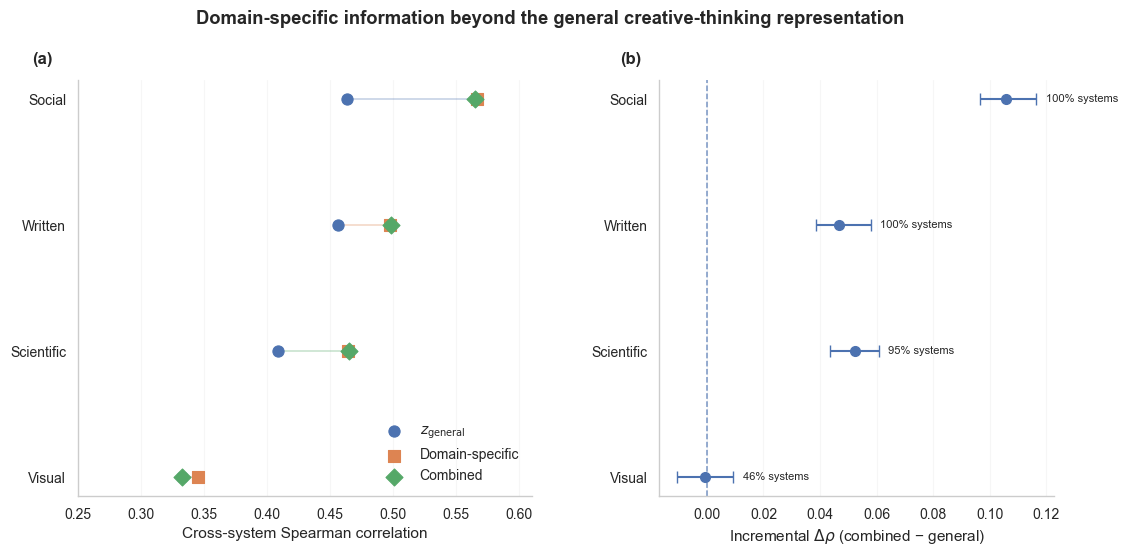

In [ ]:
# Main figure: general vs domain-specific creative representation

import matplotlib.pyplot as plt


domain_order = [
    "Social",
    "Written",
    "Scientific",
    "Visual"
]


display_df = (

    domain_increment_summary

    .set_index(
        "domain"
    )

    .loc[
        domain_order
    ]

    .reset_index()
)


bootstrap_display = (

    domain_bootstrap_df

    .set_index(
        "domain"
    )

    .loc[
        domain_order
    ]

    .reset_index()
)


fig = plt.figure(
    figsize=(
        12.6,
        5.4
    )
)


gs = fig.add_gridspec(
    1,
    2,
    width_ratios=[
        1.15,
        1.0
    ],
    wspace=0.30
)


# Panel A — representation comparison

ax1 = fig.add_subplot(
    gs[
        0,
        0
    ]
)


y = np.arange(
    len(
        domain_order
    )
)


general = (
    display_df[
        "general_rho_mean"
    ].to_numpy()
)

specific = (
    display_df[
        "domain_specific_rho_mean"
    ].to_numpy()
)

combined = (
    display_df[
        "combined_rho_mean"
    ].to_numpy()
)


# Connecting range
for i in range(
    len(
        y
    )
):

    values = [
        general[i],
        specific[i],
        combined[i]
    ]

    ax1.plot(
        [
            min(
                values
            ),
            max(
                values
            )
        ],
        [
            y[i],
            y[i]
        ],
        linewidth=1.1,
        alpha=0.35
    )


ax1.scatter(
    general,
    y,
    s=65,
    marker="o",
    label=r"$z_{\mathrm{general}}$",
    zorder=3
)


ax1.scatter(
    specific,
    y,
    s=70,
    marker="s",
    label="Domain-specific",
    zorder=3
)


ax1.scatter(
    combined,
    y,
    s=75,
    marker="D",
    label="Combined",
    zorder=3
)


ax1.set_yticks(
    y
)

ax1.set_yticklabels(
    domain_order
)

ax1.invert_yaxis()


ax1.set_xlabel(
    "Cross-system Spearman correlation"
)

ax1.set_ylabel(
    ""
)


ax1.set_xlim(
    0.25,
    0.61
)


ax1.grid(
    axis="x",
    alpha=0.16
)

ax1.grid(
    axis="y",
    visible=False
)


ax1.legend(
    frameon=False,
    loc="lower right"
)


ax1.spines[
    "top"
].set_visible(
    False
)

ax1.spines[
    "right"
].set_visible(
    False
)


ax1.text(
    -0.10,
    1.04,
    "(a)",
    transform=ax1.transAxes,
    fontsize=12,
    fontweight="semibold"
)


# Panel B — incremental value with 95% system bootstrap CI

ax2 = fig.add_subplot(
    gs[
        0,
        1
    ]
)


delta = (
    bootstrap_display[
        "delta_rho_mean"
    ].to_numpy()
)


lower = (

    delta

    -

    bootstrap_display[
        "delta_rho_ci_low"
    ].to_numpy()
)


upper = (

    bootstrap_display[
        "delta_rho_ci_high"
    ].to_numpy()

    -

    delta
)


ax2.errorbar(

    delta,
    y,

    xerr=np.vstack(
        [
            lower,
            upper
        ]
    ),

    fmt="o",

    markersize=7,

    capsize=4,

    linewidth=1.5
)


ax2.axvline(
    0.0,
    linestyle="--",
    linewidth=1.1,
    alpha=0.75
)


ax2.set_yticks(
    y
)

ax2.set_yticklabels(
    domain_order
)

ax2.invert_yaxis()


ax2.set_xlabel(
    r"Incremental $\Delta\rho$ "
    "(combined − general)"
)

ax2.set_ylabel(
    ""
)


ax2.grid(
    axis="x",
    alpha=0.16
)

ax2.grid(
    axis="y",
    visible=False
)


ax2.spines[
    "top"
].set_visible(
    False
)

ax2.spines[
    "right"
].set_visible(
    False
)


# Add prevalence labels.
for i, row in (
    bootstrap_display
    .iterrows()
):

    pct = (
        row[
            "pct_systems_positive_delta_rho"
        ]
    )

    ax2.annotate(

        f"{pct:.0f}% systems",

        (
            row[
                "delta_rho_ci_high"
            ],
            i
        ),

        xytext=(
            7,
            0
        ),

        textcoords="offset points",

        va="center",

        fontsize=8
    )


ax2.text(
    -0.10,
    1.04,
    "(b)",
    transform=ax2.transAxes,
    fontsize=12,
    fontweight="semibold"
)


fig.suptitle(
    "Domain-specific information beyond the general "
    "creative-thinking representation",
    fontsize=13.2,
    fontweight="semibold",
    y=1.01
)


fig.tight_layout()


fig.savefig(
    FIG_DIR
    / "crest_general_vs_domain_specific.pdf",
    bbox_inches="tight"
)


fig.savefig(
    FIG_DIR
    / "crest_general_vs_domain_specific.png",
    dpi=400,
    bbox_inches="tight"
)


plt.show()